# Individual Analysis of Online Anomaly Detectors with PV Datasets 

In [ ]:
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path
from sklearn.metrics import roc_auc_score, auc, precision_recall_curve, roc_curve
import logging
from concurrent.futures import ThreadPoolExecutor, as_completed
import warnings
pd.set_option('display.max_colwidth', None)

In [ ]:
TYPE_WS = "params_with_p_window_size" #params_with_p_window_size or params_with_window
COD_SCENARIO = 'DA1' #Cod of Datasets used for tuning: DA3, 116
#METHODS_TO_ANALYSE = ["IForestASD", "KitNet", "mDragStream", "RSHash", "ExactStorm", "HStree", "xStream", "oIF", "SWLOF", "OnlineBootKNN", "RobustRandomCutForest"]
#METHODS_TO_ANALYSE = ["IForestASD", "HStree", "oIF", "RobustRandomCutForest"] # Decisition-Tree based methods
METHODS_TO_ANALYSE = ["IForestASD","KitNet","oIF","OnlineBootKNN","ExactStorm"] 

In [309]:
# --- Setup ---
# Configure logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# Hiding Warnings
warnings.filterwarnings("ignore", message="use_inf_as_na option is deprecated")



# --- Path Definitions ---
current_dir = Path.cwd().parent


# Initialize a list to hold all directories to be processed
input_dirs = []

input_dirs.append(current_dir / "datasets" / "processed_own_method_V2_tuning_public_ds")
input_dirs.append(current_dir / "datasets" / "processed_sota_method_tuning_public_ds")
input_dirs.append(current_dir / "datasets" / "processed_own_method_V2_tuning_pv_ds")
input_dirs.append(current_dir / "datasets" / "processed_sota_method_tuning_pv_ds")

input_dirs.append(current_dir / "datasets" / "processed_own_method_V2_eval_public_ds")
input_dirs.append(current_dir / "datasets" / "processed_sota_method_eval_public_ds")
input_dirs.append(current_dir / "datasets" / "processed_own_method_V2_eval_pv_ds")
input_dirs.append(current_dir / "datasets" / "processed_sota_method_eval_pv_ds")

input_dirs.append(current_dir / "datasets" / "processed_own_method_V2_eval_pv_gtv2_ds")
input_dirs.append(current_dir / "datasets" / "processed_sota_method_eval_pv_gtv2_ds")
input_dirs.append(current_dir / "datasets" / "processed_own_method_V2_with_ef_current_eval_pv_bv5_gtv2_ds")
input_dirs.append(current_dir / "datasets" / "processed_sota_method_with_ef_current_eval_pv_bv5_gtv2_ds")

# --- Get all Excel files from the determined directories ---
files_to_process = []
for directory in input_dirs:
    if not directory.exists():
        logging.warning(f"Input directory does not exist, skipping: {directory}")
        continue  # Skip to the next directory

    # Find matching files and add them to the list
    found_files = [f for f in directory.iterdir() if
                (f.suffix == '.xlsx' and '_' in f.name) and
                (f.stem.split("_")[0] == COD_SCENARIO) and
                any(part in METHODS_TO_ANALYSE for part in f.stem.split("_"))]
    files_to_process.extend(found_files)
    logging.info(f"Found {len(found_files)} files to process in {directory.name}")

# --- Final Check ---
if not files_to_process:
    logging.error("No files found to process in the specified directories. Exiting.")
    sys.exit(1) # Exit if no files were found at all

logging.info(f"Total files to process from all sources: {len(files_to_process)}")


def process_group(group, file_name, iteration, method, mwp, p_window_size, scn):
    """Calculates performance metrics for a single group within a file."""

    logging.info(f"Data Retrieved for {file_name} | Iter {iteration} | Method {method} | Scenario {scn}")

    return group, file_name, iteration, method, mwp, p_window_size, scn

def process_file(file_path):
    """Processes a single Excel file, parallelizing its internal groups."""
    
    
    try:
        
        logging.info(f"Processing file: {file_path.name}")
        df = pd.read_excel(file_path)

    except Exception as e:
        logging.error(f"Could not read {file_path.name}: {e}")
        return [] # Return empty list on failure

    df['scenario'] = file_path.name.split("_")[0]

    # Extract window size and create a unique identifier for method/window/param
    window = file_path.name.split("_")[-1].replace('.xlsx', '')
    
    df['method_window_and_param'] = df['method'] + "_" + window + "_" + df['param'].astype(str)
    df['window_size'] = window
    df['p_window_size'] = int(window)/len(df)

    grouped = df.groupby(["iteration", "method","method_window_and_param","p_window_size", "scenario"])
    local_summary_data = []

    # Use ThreadPoolExecutor to parallelize processing of groups within the file
    with ThreadPoolExecutor(max_workers=os.cpu_count()) as executor:
        future_to_group = {
            executor.submit(process_group, group, file_path.name, iteration, method, mwp, p_window_size, scn): (iteration, method, mwp, p_window_size, scn)
            for (iteration, method, mwp, p_window_size, scn), group in grouped
        }

        for future in as_completed(future_to_group):
            result = future.result()
            if result:
                local_summary_data.append(result)

    return local_summary_data


# --- Main Execution ---
concatenated_df = []

with ThreadPoolExecutor(max_workers=os.cpu_count()) as executor:
    # Create a future for each file to be processed
    future_to_file = {executor.submit(process_file, path): path for path in files_to_process}
    for future in as_completed(future_to_file):
        
        file_path = future_to_file[future]

        try:
            # Result from process_file is a list of summary dictionaries
            file_data = future.result()
            if file_data:
                concatenated_df.extend(file_data)
        except Exception as e:
            logging.error(f"Error processing file {file_path.name}: {e}")



2026-05-22 09:21:42,425 - INFO - Data Retrieved for DA1_20250609_results_ExactStorm_iter_2_paramset_0_PV_ds_ws_840.xlsx | Iter 2 | Method ExactStorm | Scenario DA1
2026-05-22 09:21:42,497 - INFO - Processing file: DA1_20250609_results_ExactStorm_iter_1_paramset_0_PV_ds_ws_840.xlsx
2026-05-22 09:21:43,120 - INFO - Data Retrieved for DA1_20250609_results_KitNet_iter_2_paramset_0_PV_ds_ws_210.xlsx | Iter 2 | Method KitNet | Scenario DA1
2026-05-22 09:21:43,185 - INFO - Processing file: DA1_20250609_results_ExactStorm_iter_0_paramset_0_PV_ds_ws_840.xlsx
2026-05-22 09:21:43,798 - INFO - Data Retrieved for DA1_20250609_results_KitNet_iter_1_paramset_0_PV_ds_ws_210.xlsx | Iter 1 | Method KitNet | Scenario DA1
2026-05-22 09:21:43,825 - INFO - Processing file: DA1_20250609_results_KitNet_iter_0_paramset_0_PV_ds_ws_210.xlsx
2026-05-22 09:21:43,862 - INFO - Data Retrieved for DA1_20250609_results_IForestASD_iter_2_paramset_0_PV_ds_ws_840.xlsx | Iter 2 | Method IForestASD | Scenario DA1
2026-05-22

In [310]:
# --- Final Concatenation ---

# 1. Extract only the DataFrame object from each tuple in the list
list_of_dataframes = [item[0] for item in concatenated_df]

# 2. Concatenate the list of DataFrames into a single DataFrame
#    - `ignore_index=True` is important to create a new, clean index for the final DataFrame.
df = pd.concat(list_of_dataframes, ignore_index=True)
df['scenario'].unique()

array(['DA1'], dtype=object)

In [311]:
df['method_window_and_param'] = df['method_window_and_param'].str.replace("OnlineBootKNN_TNone", "OBKNN (TNone)")
df['method_window_and_param'] = df['method_window_and_param'].str.replace("OnlineBootKNN_TZnorm", "OBKNN (TZNorm)")

# Shortening the name of the methods
new_method_name = {"xStream":"XStream", 
"RSHash":"RSHash", "IForestASD":"IFASD", "RobustRandomCutForest":"RRCF", "KitNet":"KitNet", "ExactStorm":"EStorm","oIF":"OIF", "HStree":"HStree", "OnlineBootKNN":"OBKNN",
"SFxStream":"SFXStream", 
"SFRSHash":"SFRSHash", "SFIForestASD":"SFIFASD", "SFRobustRandomCutForest":"SFRRCF", "SFKitNet":"SFKitNet", "SFExactStorm":"SFEStorm","SFoIF":"SFOIF", "SFHStree":"SFHStree", "SFOnlineBootKNN":"SFOBKNN"
} 

df["method"] = df['method'].replace(new_method_name)

mask_none = (df['method'] == 'OBKNN') & \
           (df['method_window_and_param'].str.contains('NONE', case=False, na=False))
df.loc[mask_none, 'method'] = 'OBKNN (None)'

# Case 2: ZNormalization
mask_znorm = (df['method'] == 'OBKNN') & \
           (df['method_window_and_param'].str.contains('ZNORM', case=False, na=False))
df.loc[mask_znorm, 'method'] = 'OBKNN (ZNorm)'

In [312]:
df.columns

Index(['iteration', 'timestamp', 'method', 'param', 'score', 'cleaned_score',
       'training_time', 'scoring_time', 'ground_truth', 'error_type_score',
       'scenario', 'method_window_and_param', 'window_size', 'p_window_size'],
      dtype='object')

In [313]:
df["param"].unique()

array(["{'algorithm': 'brute', 'alpha_ema': 0.01, 'alpha_z_test': 0.05, 'chunk_size': 30, 'dmetric': 'cityblock', 'ensemble_size': 30, 'n_jobs': -1, 'no_bootstrapp': False, 'no_z_score': False, 'p_window_size': 0.2, 'transf': 'ZNORM', 'type_dist': 'largest', 'update_distance_with_abnormal': True, 'update_mode_stats': 'welford'}",
       "{'algorithm': 'brute', 'alpha_ema': 0.01, 'alpha_z_test': 0.05, 'chunk_size': 30, 'dmetric': 'cityblock', 'ensemble_size': 30, 'n_jobs': -1, 'no_bootstrapp': False, 'no_z_score': False, 'p_window_size': 0.2, 'transf': 'NONE', 'type_dist': 'largest', 'update_distance_with_abnormal': False, 'update_mode_stats': 'ema'}",
       "{'max_radius': 900, 'p_window_size': 0.2}",
       "{'hidden_ratio': 0.9, 'learning_rate': 0.1, 'max_size_ae': 10, 'p_window_size': 0.05}",
       "{'initial_window_X': None, 'p_window_size': 0.2}",
       "{'growth_criterion': 'fixed', 'max_leaf_samples': 64, 'n_jobs': -1, 'num_trees': 64, 'p_window_size': 0.2}"],
      dtype=obj

In [314]:


df["timestamp"] = pd.to_datetime(df["timestamp"])
df['scenario_method_window_and_param'] = df['scenario'] + "_" + df['method_window_and_param'].astype(str)

if COD_SCENARIO in ['DA3', '116']: #Scenarios used for tuning
    # Creating new column params_with_window
    df["params_with_p_window_size"] = "{'p_window_size': " + df["p_window_size"].astype(str)+df["param"].str.replace("{", ", ", regex=False)
    df["params_with_p_window_size"] = df["params_with_p_window_size"].str.replace("}_{", ",", regex=False)
else:
    df["params_with_p_window_size"] = df["param"]


df["params_with_window"] = "{'window_size': " + df["window_size"].astype(str)+df["param"].str.replace("{", ", ", regex=False)
df["params_with_window"] = df["params_with_window"].str.replace("}_{", ",", regex=False)



In [315]:
final_df = df



In [316]:
# Get the final list of unique merged combinations
methods = final_df.method.unique()
params = final_df.param.unique()
method_window_and_param = final_df["method_window_and_param"].unique()
scenario_method_window_and_param = final_df["scenario_method_window_and_param"].unique()
acol = "scenario_method_window_and_param"
tecnique = scenario_method_window_and_param
print(method_window_and_param)

["OBKNN (TZNorm)_840_{'algorithm': 'brute', 'alpha_ema': 0.01, 'alpha_z_test': 0.05, 'chunk_size': 30, 'dmetric': 'cityblock', 'ensemble_size': 30, 'n_jobs': -1, 'no_bootstrapp': False, 'no_z_score': False, 'p_window_size': 0.2, 'transf': 'ZNORM', 'type_dist': 'largest', 'update_distance_with_abnormal': True, 'update_mode_stats': 'welford'}"
 "OBKNN (TNone)_840_{'algorithm': 'brute', 'alpha_ema': 0.01, 'alpha_z_test': 0.05, 'chunk_size': 30, 'dmetric': 'cityblock', 'ensemble_size': 30, 'n_jobs': -1, 'no_bootstrapp': False, 'no_z_score': False, 'p_window_size': 0.2, 'transf': 'NONE', 'type_dist': 'largest', 'update_distance_with_abnormal': False, 'update_mode_stats': 'ema'}"
 "ExactStorm_840_{'max_radius': 900, 'p_window_size': 0.2}"
 "KitNet_210_{'hidden_ratio': 0.9, 'learning_rate': 0.1, 'max_size_ae': 10, 'p_window_size': 0.05}"
 "IForestASD_840_{'initial_window_X': None, 'p_window_size': 0.2}"
 "oIF_840_{'growth_criterion': 'fixed', 'max_leaf_samples': 64, 'n_jobs': -1, 'num_trees':

In [317]:
num_colors = len(tecnique)

#num_colors = len(methods)
print("Total Tecniques Considered: ", num_colors)


Total Tecniques Considered:  6


In [318]:
#methods = np.array(['RSHash', 'RobustRandomCutForest', 'KitNet', 'ExactStorm', 'IForestASD', 'oIF', 'HStree', 'OnlineBootKNN','xStream'], dtype=object)

In [319]:
# Lista completa recuperada
colors = [
    '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf',
    '#aec7e8', '#ffbb78', '#98df8a', '#ff9896', '#c5b0d5', '#c49c94', '#f7b6d2', '#c7c7c7', '#dbdb8d', '#9edae5',
    '#393b79', '#5254a3', '#6b6ecf', '#9c9ede', '#637939', '#8ca252', '#b5cf6b', '#cedb9c', '#8c6d31', '#bd9e39',
    '#e7ba52', '#e7cb94', '#843c39', '#ad494a', '#d6616b', '#e7969c', '#7b4173', '#a55194', '#ce6dbd', '#de9ed6',
    '#a6cee3', '#b2df8a', '#33a02c', '#fb9a99', '#e31a1c', '#fdbf6f', '#ff7f00', '#cab2d6', '#6a3d9a', '#ffff99',
    '#b15928', '#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00', '#ffff33', '#a65628', '#f781bf', '#999999',
    '#66c2a4', '#fc8d62', '#8da0cb', '#e78ac3', '#a6d854', '#ffd92f', '#e5c494', '#b3b3b3', '#8dd3c7', '#ffffb3',
    '#bebada', '#fb8072', '#80b1d3', '#fdb462', '#b3de69', '#fccde5', '#d9d9d9', '#bc80bd', '#ccebc5', '#ffed6f',
    '#7fc97f', '#beaed4', '#fdc086', '#ffff99', '#386cb0', '#f0027f', '#bf5b17', '#666666', '#e6ab02', '#a6761d',
    '#66a61e', '#e7298a', '#e64b35', '#440154', '#482475', '#414487', '#355f8d', '#2a788e', '#21918c', '#22a884',
    '#42be71', '#7ad151', '#bddf26', '#fde725', '#440154', '#472d7b', '#3e4989', '#31688e', '#26828e', '#1f9e89',
    '#35b779', '#6dcd59', '#b4de2c', '#fcd22e', '#0d0887', '#41049d', '#6a00a8', '#8f0da4', '#b12a90', '#cc4778',
    '#e16462', '#f2844b', '#fca636', '#fcce25', '#0d0887', '#41049d', '#6a00a8', '#8f0da4', '#b12a90', '#cc4778',
    '#e16462', '#f2844b', '#fca636', '#fcce25', '#f0f921', '#000004', '#1b0f41', '#3f0f67', '#631b6e', '#882e6c',
    '#ac4065', '#ce565a', '#e9705a', '#f8915c', '#febc5c', '#fdf362', '#000004', '#1b0f41', '#3f0f67', '#631b6e',
    '#882e6c', '#ac4065', '#ce565a', '#e9705a', '#f8915c', '#febc5c', '#fdf362', '#000004', '#1b0f41', '#3f0f67',
    '#631b6e', '#882e6c', '#ac4065', '#ce565a', '#e9705a', '#f8915c', '#febc5c', '#fdf362', '#000004', '#1b0f41',
    '#3f0f67', '#631b6e', '#882e6c', '#ac4065', '#ce565a', '#e9705a', '#f8915c', '#febc5c', '#fdf362', '#000004',
    '#1b0f41', '#3f0f67', '#631b6e', '#882e6c', '#ac4065', '#ce565a', '#e9705a', '#f8915c', '#febc5c'
]

# Asegúrate de que num_colors coincida con la longitud de tecnique
num_colors = len(tecnique)
color_list = colors[:num_colors]

In [320]:
iterations = final_df["iteration"].unique()[0:10]
iterations

array([0, 2, 1])

## Individual Score of Online Anomaly Detectors with PV Datasets 

In [321]:
FONTSIZE_MAIN = 14
FONTSIZE_SEC = 13

Plotting method: DA1_OBKNN (TZNorm)_840_{'algorithm': 'brute', 'alpha_ema': 0.01, 'alpha_z_test': 0.05, 'chunk_size': 30, 'dmetric': 'cityblock', 'ensemble_size': 30, 'n_jobs': -1, 'no_bootstrapp': False, 'no_z_score': False, 'p_window_size': 0.2, 'transf': 'ZNORM', 'type_dist': 'largest', 'update_distance_with_abnormal': True, 'update_mode_stats': 'welford'}


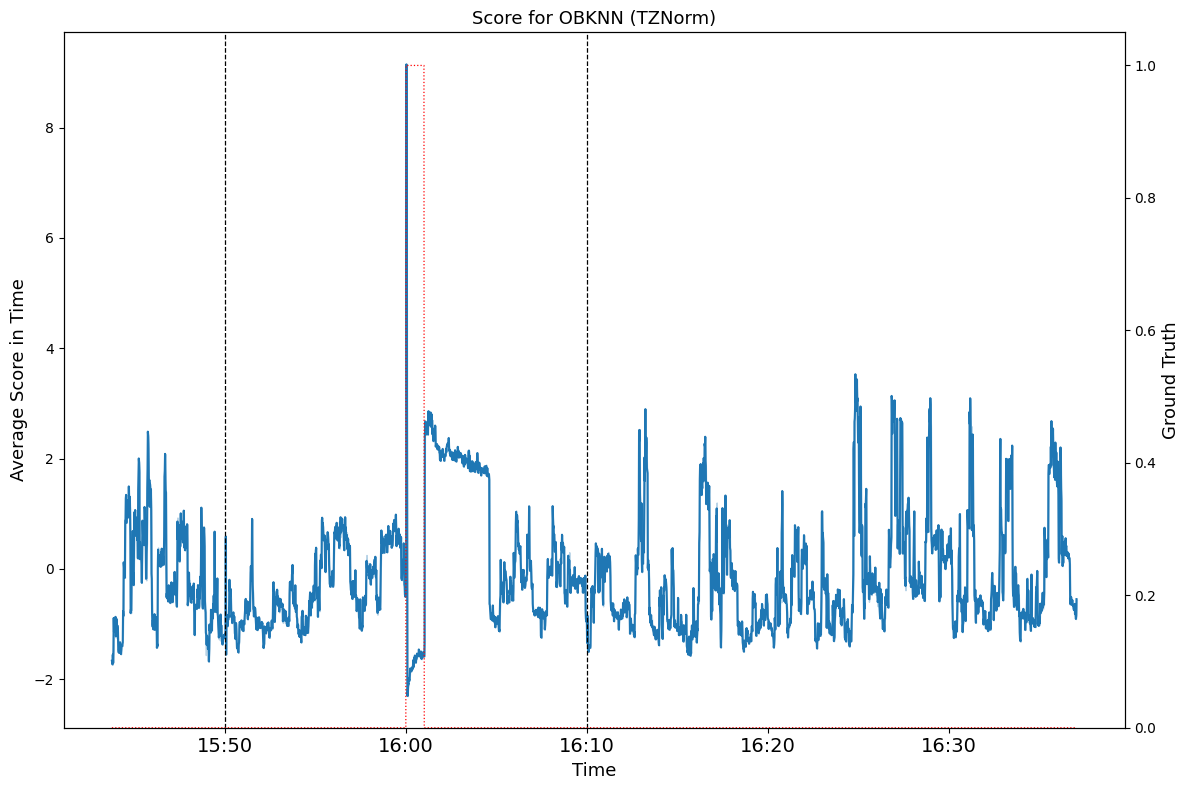

Plotting method: DA1_OBKNN (TNone)_840_{'algorithm': 'brute', 'alpha_ema': 0.01, 'alpha_z_test': 0.05, 'chunk_size': 30, 'dmetric': 'cityblock', 'ensemble_size': 30, 'n_jobs': -1, 'no_bootstrapp': False, 'no_z_score': False, 'p_window_size': 0.2, 'transf': 'NONE', 'type_dist': 'largest', 'update_distance_with_abnormal': False, 'update_mode_stats': 'ema'}


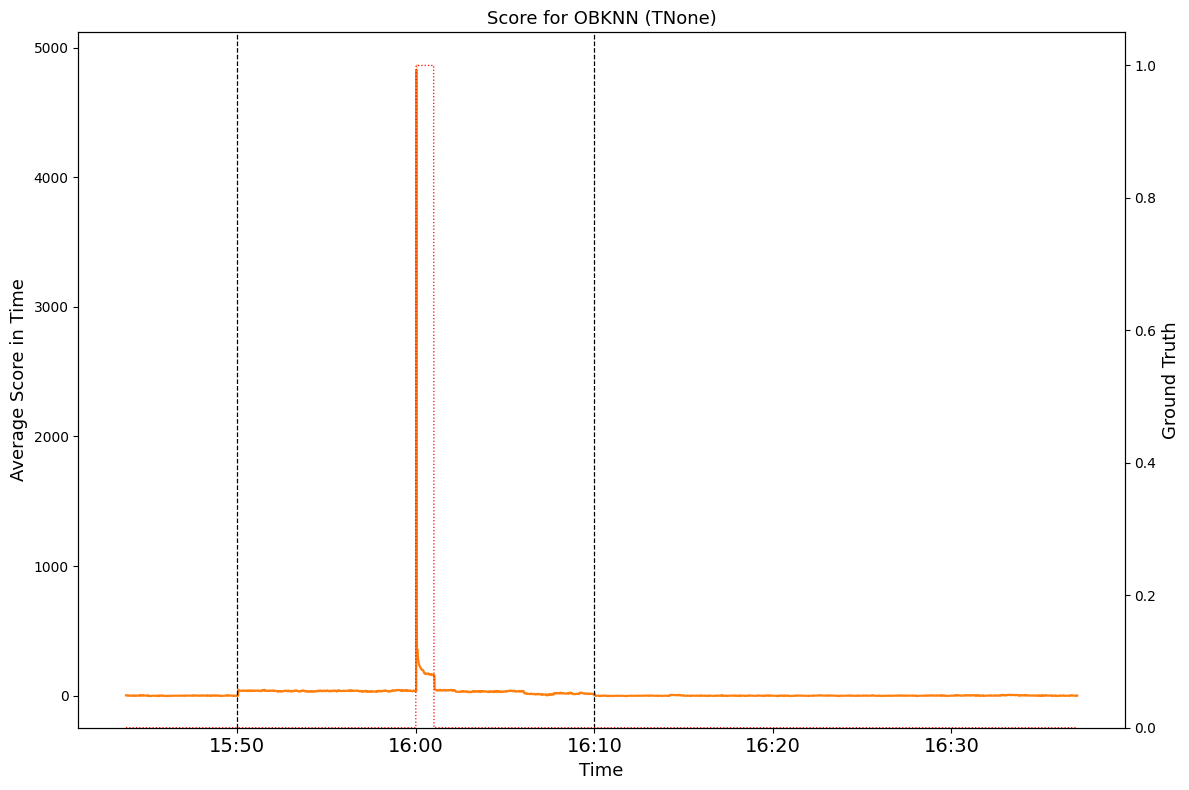

Plotting method: DA1_ExactStorm_840_{'max_radius': 900, 'p_window_size': 0.2}


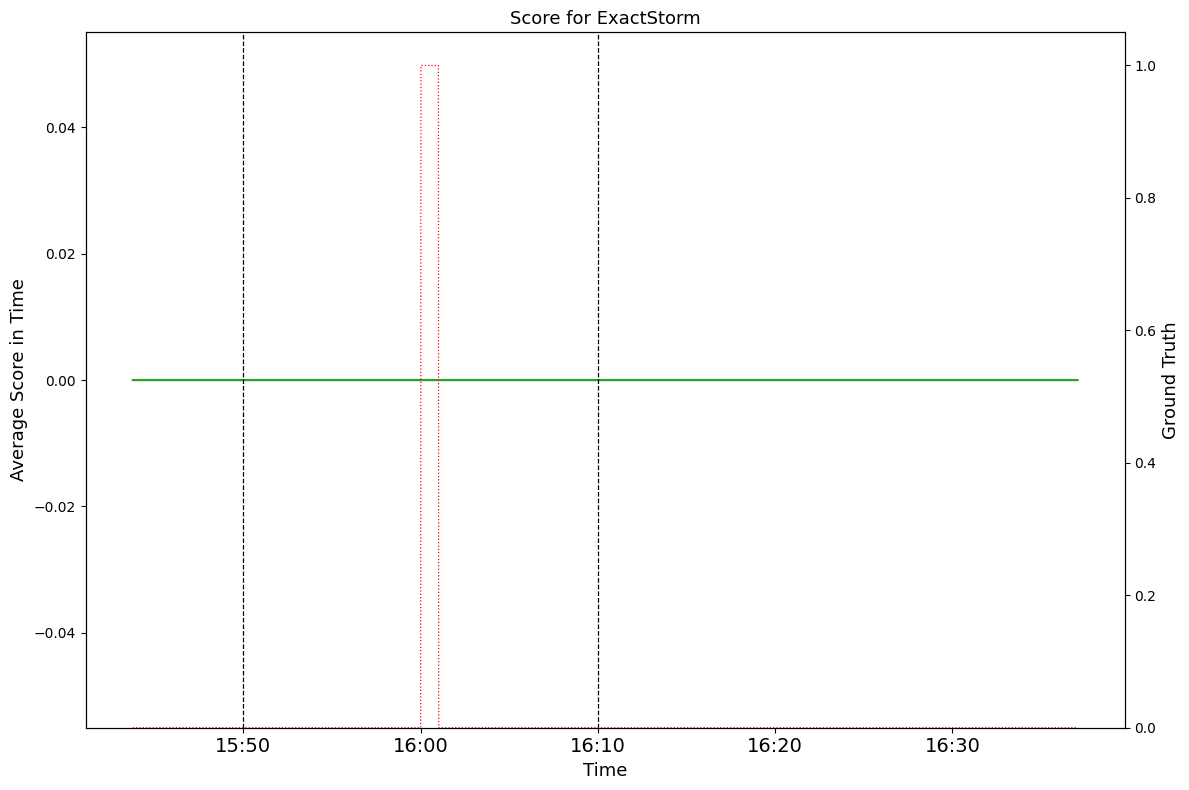

Plotting method: DA1_KitNet_210_{'hidden_ratio': 0.9, 'learning_rate': 0.1, 'max_size_ae': 10, 'p_window_size': 0.05}


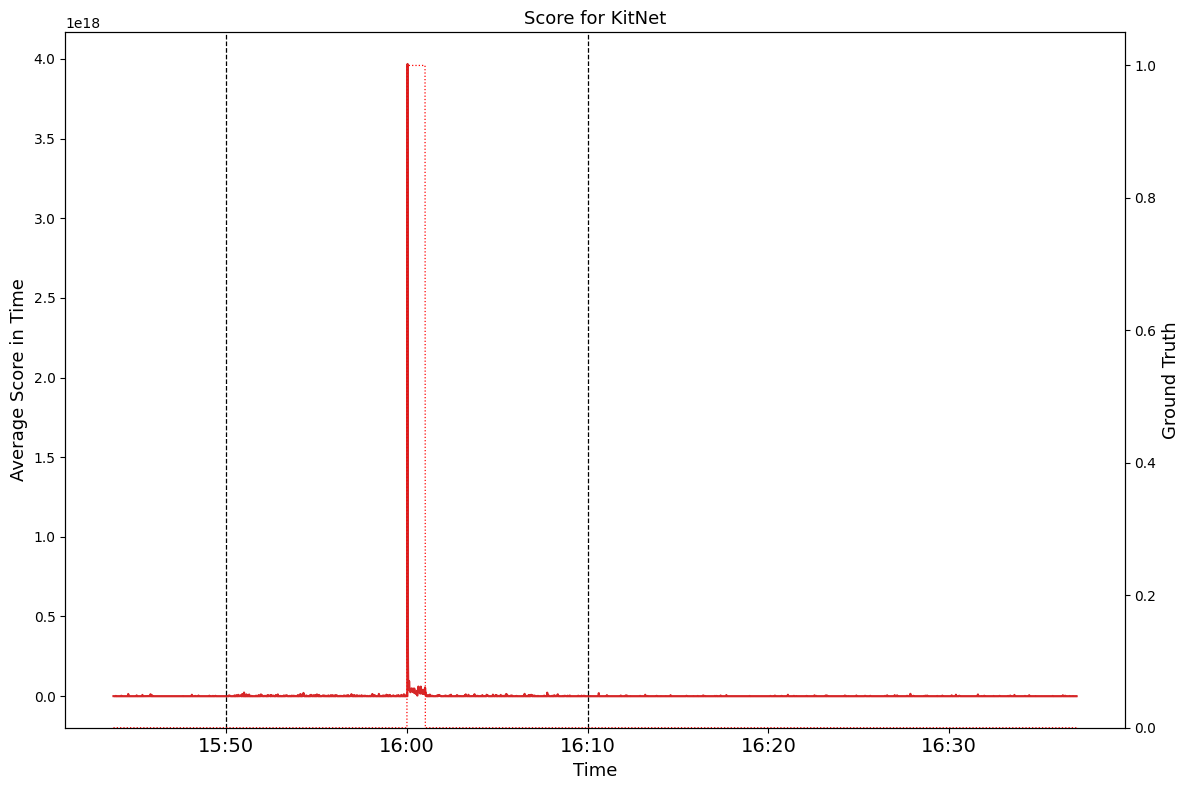

Plotting method: DA1_IForestASD_840_{'initial_window_X': None, 'p_window_size': 0.2}


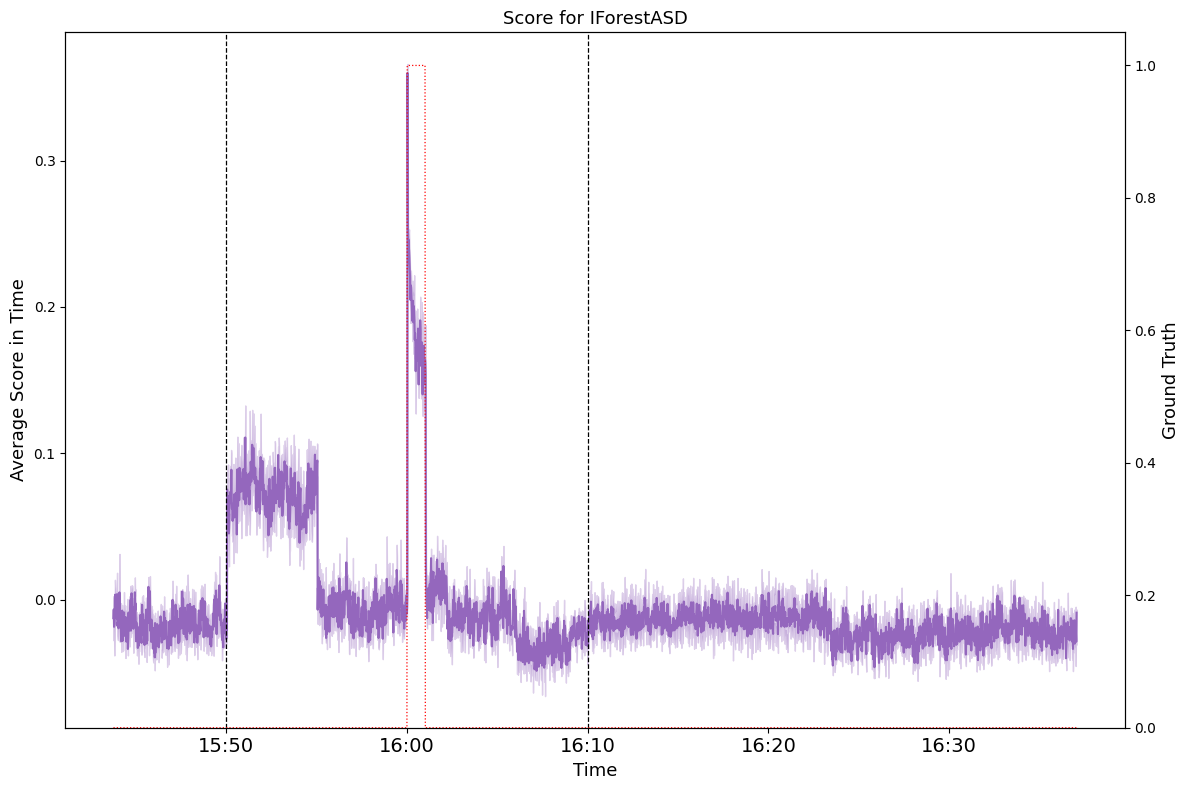

Plotting method: DA1_oIF_840_{'growth_criterion': 'fixed', 'max_leaf_samples': 64, 'n_jobs': -1, 'num_trees': 64, 'p_window_size': 0.2}


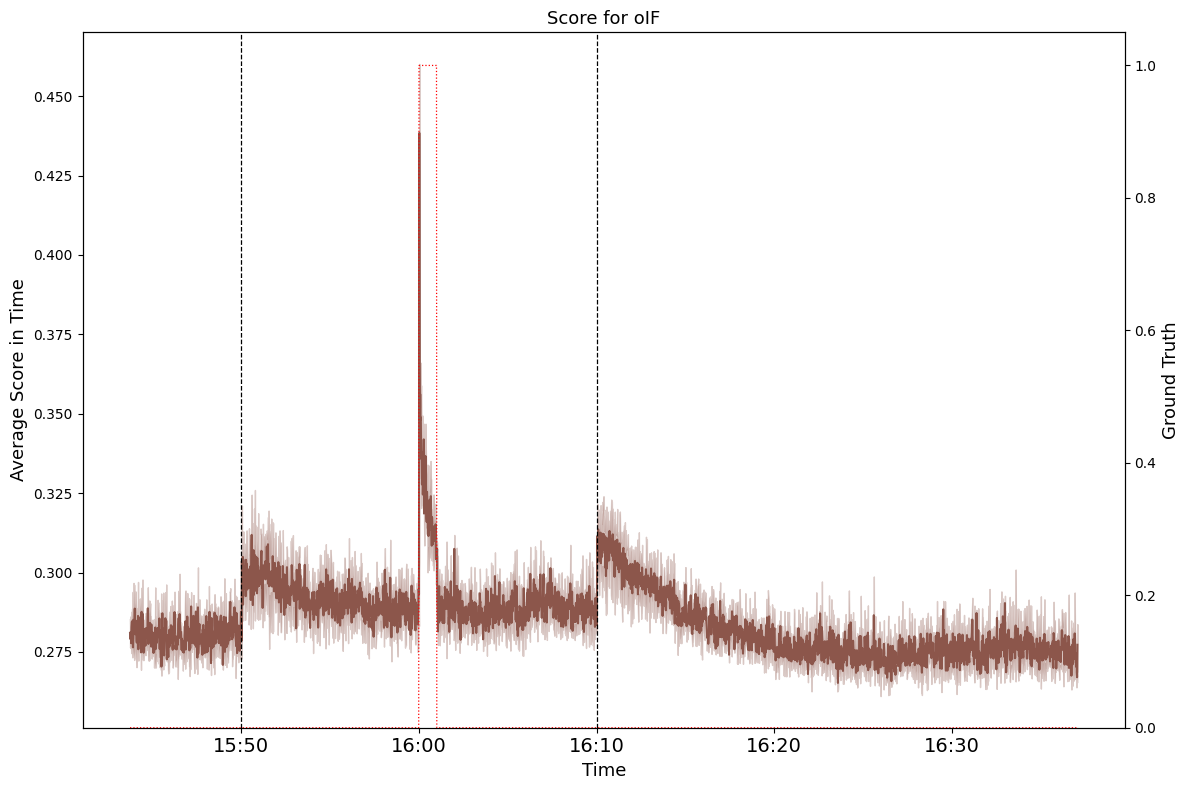

In [322]:
average_results = final_df.groupby([acol, 'timestamp'], as_index=False).agg(
    mean_score=('cleaned_score', 'mean'),
    std_score=('cleaned_score', 'std'),
    mean_gt=('ground_truth', 'mean'),
    window_size=('window_size', 'first')
)

drift_start = pd.to_datetime('15:50').replace(year=2025, month=6, day=9)
drift_end = pd.to_datetime('16:10').replace(year=2025, month=6, day=9)

for m, color in zip(tecnique, color_list):
    print(f"Plotting method: {m}")
    fig, ax1 = plt.subplots(figsize=(12, 8))
    
    method_data = average_results[(average_results[acol] == m)].copy()
    N = len(method_data) - 1000
    method_data = method_data.tail(N)

    # 1. Plot Score medio
    ax1.plot(
        method_data['timestamp'], 
        method_data['mean_score'], 
        label=f'{m}', 
        color=color
    )
    
    # 2. Área sombreada
    ax1.fill_between(
        method_data['timestamp'], 
        method_data['mean_score'] - method_data['std_score'], 
        method_data['mean_score'] + method_data['std_score'], 
        color=color, alpha=0.3
    )

    # 3. Líneas de Drift (mismo grosor que el GT)
    ax1.axvline(x=drift_start, color='black', linestyle='--', linewidth=0.9)
    ax1.axvline(x=drift_end, color='black', linestyle='--', linewidth=0.9)

    # 4. Ground Truth (Línea punteada)
    ax2 = ax1.twinx()
    ax2.plot(
        method_data['timestamp'], 
        method_data['mean_gt'], 
        color='red',
        linestyle=':',
        linewidth=0.9
    )
    
    ax1.set_xlabel('Time', fontsize=FONTSIZE_SEC)
    ax1.set_ylabel('Average Score in Time', fontsize=FONTSIZE_SEC)
    
    title_name = m.split('_')[1] if '_' in m else m
    ax1.set_title(f"Score for {title_name}", fontsize=FONTSIZE_SEC)
    
    ax2.set_ylabel('Ground Truth', fontsize=FONTSIZE_SEC)
    ax2.set_ylim(0, 1.05)

    ax1.grid(False)
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax1.tick_params(axis='x', labelsize=FONTSIZE_MAIN)
    plt.xticks(rotation=45, fontsize=FONTSIZE_MAIN)
    plt.tight_layout()

    save_name = m.split('_')[1] if '_' in m else m
    plt.savefig(current_dir / 'notebooks' / 'score_functions' / f"{COD_SCENARIO}_score_{save_name}.pdf", format="pdf")
    plt.show()

Method: DA1_OBKNN (TZNorm)_840_{'algorithm': 'brute', 'alpha_ema': 0.01, 'alpha_z_test': 0.05, 'chunk_size': 30, 'dmetric': 'cityblock', 'ensemble_size': 30, 'n_jobs': -1, 'no_bootstrapp': False, 'no_z_score': False, 'p_window_size': 0.2, 'transf': 'ZNORM', 'type_dist': 'largest', 'update_distance_with_abnormal': True, 'update_mode_stats': 'welford'}, Iteration: 0
Method: DA1_OBKNN (TZNorm)_840_{'algorithm': 'brute', 'alpha_ema': 0.01, 'alpha_z_test': 0.05, 'chunk_size': 30, 'dmetric': 'cityblock', 'ensemble_size': 30, 'n_jobs': -1, 'no_bootstrapp': False, 'no_z_score': False, 'p_window_size': 0.2, 'transf': 'ZNORM', 'type_dist': 'largest', 'update_distance_with_abnormal': True, 'update_mode_stats': 'welford'}, Iteration: 2
Method: DA1_OBKNN (TZNorm)_840_{'algorithm': 'brute', 'alpha_ema': 0.01, 'alpha_z_test': 0.05, 'chunk_size': 30, 'dmetric': 'cityblock', 'ensemble_size': 30, 'n_jobs': -1, 'no_bootstrapp': False, 'no_z_score': False, 'p_window_size': 0.2, 'transf': 'ZNORM', 'type_di

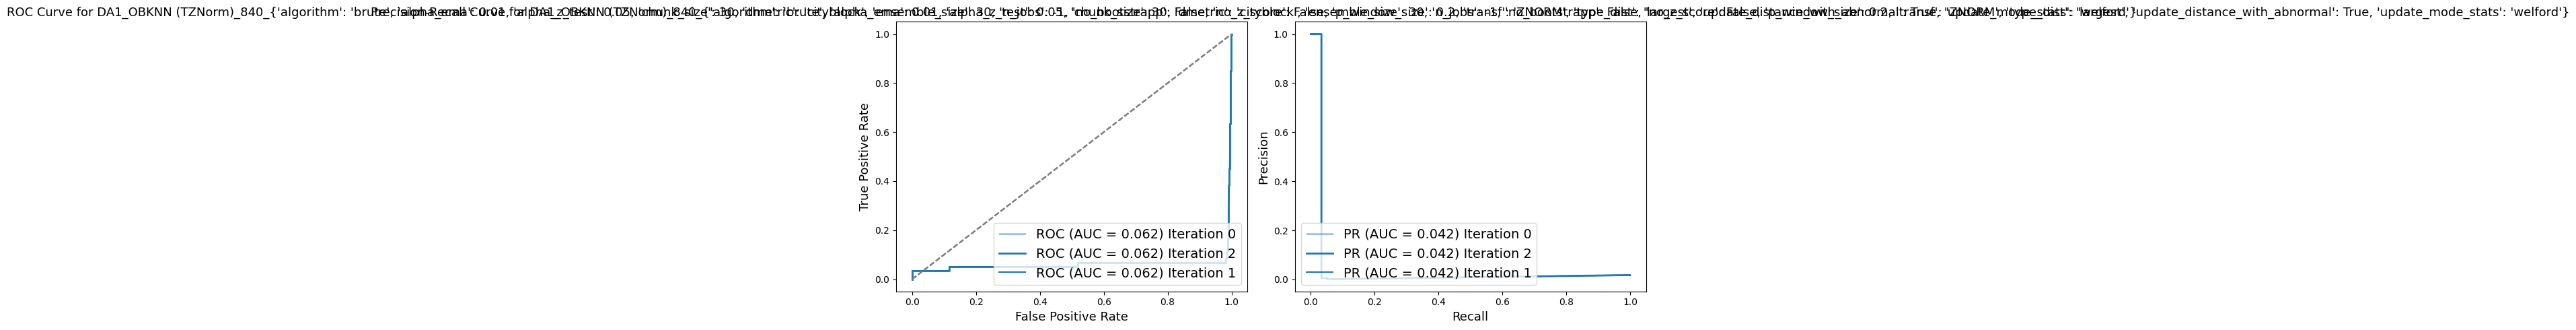

Method: DA1_OBKNN (TNone)_840_{'algorithm': 'brute', 'alpha_ema': 0.01, 'alpha_z_test': 0.05, 'chunk_size': 30, 'dmetric': 'cityblock', 'ensemble_size': 30, 'n_jobs': -1, 'no_bootstrapp': False, 'no_z_score': False, 'p_window_size': 0.2, 'transf': 'NONE', 'type_dist': 'largest', 'update_distance_with_abnormal': False, 'update_mode_stats': 'ema'}, Iteration: 1
Method: DA1_OBKNN (TNone)_840_{'algorithm': 'brute', 'alpha_ema': 0.01, 'alpha_z_test': 0.05, 'chunk_size': 30, 'dmetric': 'cityblock', 'ensemble_size': 30, 'n_jobs': -1, 'no_bootstrapp': False, 'no_z_score': False, 'p_window_size': 0.2, 'transf': 'NONE', 'type_dist': 'largest', 'update_distance_with_abnormal': False, 'update_mode_stats': 'ema'}, Iteration: 0
Method: DA1_OBKNN (TNone)_840_{'algorithm': 'brute', 'alpha_ema': 0.01, 'alpha_z_test': 0.05, 'chunk_size': 30, 'dmetric': 'cityblock', 'ensemble_size': 30, 'n_jobs': -1, 'no_bootstrapp': False, 'no_z_score': False, 'p_window_size': 0.2, 'transf': 'NONE', 'type_dist': 'larges

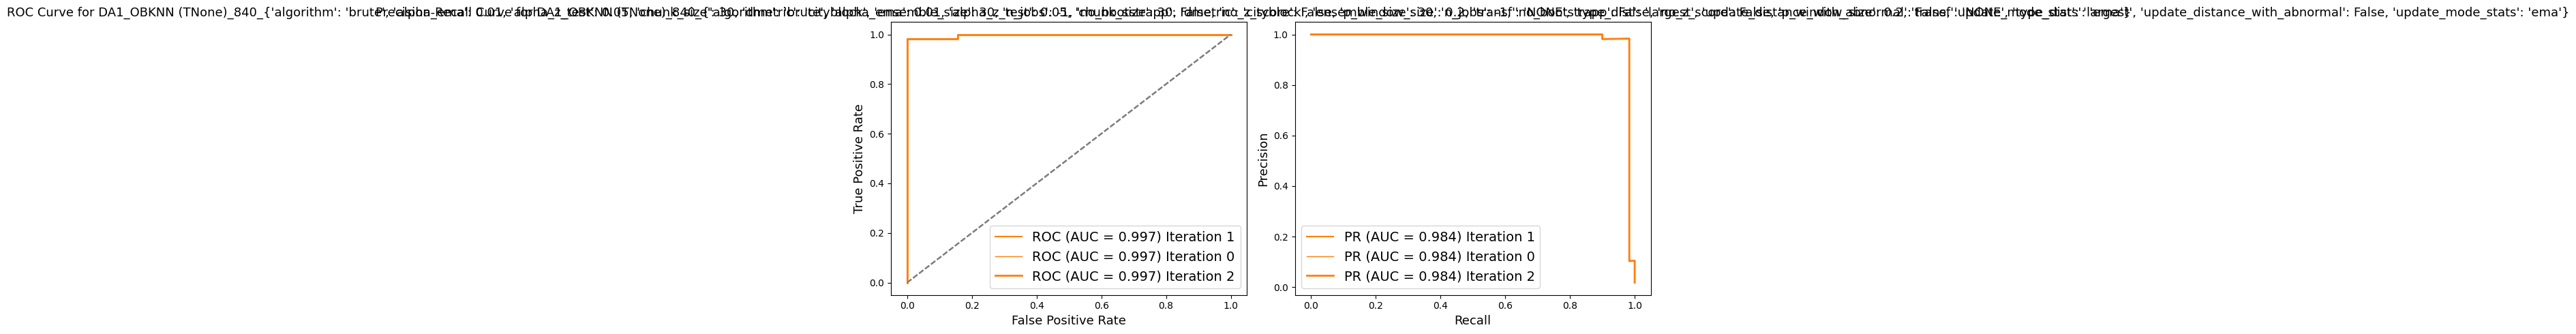

Method: DA1_ExactStorm_840_{'max_radius': 900, 'p_window_size': 0.2}, Iteration: 2
Method: DA1_ExactStorm_840_{'max_radius': 900, 'p_window_size': 0.2}, Iteration: 1
Method: DA1_ExactStorm_840_{'max_radius': 900, 'p_window_size': 0.2}, Iteration: 0


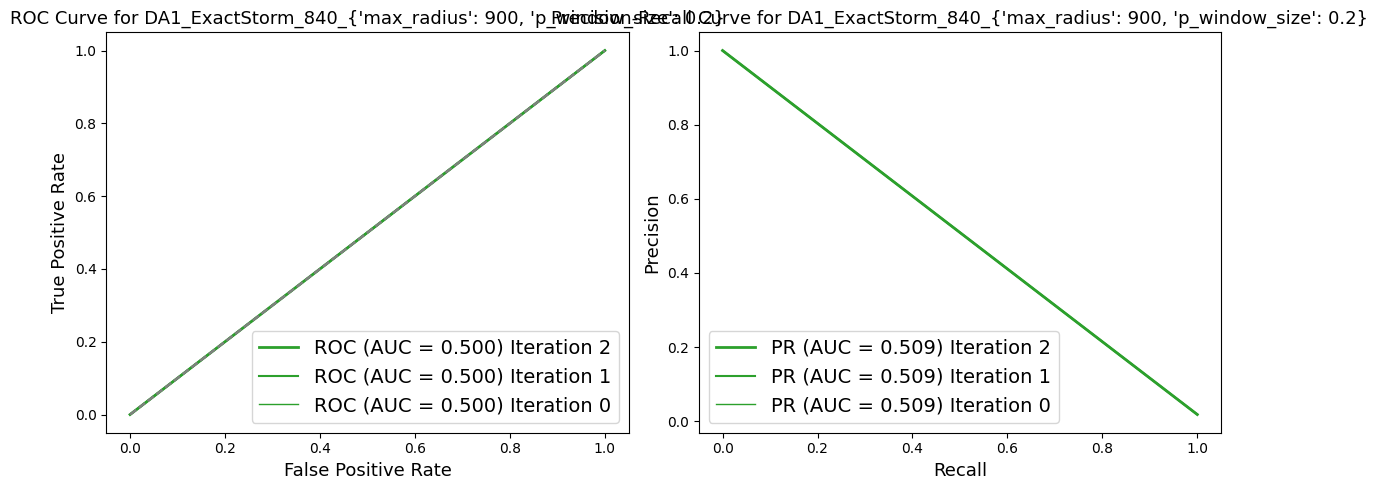

Method: DA1_KitNet_210_{'hidden_ratio': 0.9, 'learning_rate': 0.1, 'max_size_ae': 10, 'p_window_size': 0.05}, Iteration: 2
Method: DA1_KitNet_210_{'hidden_ratio': 0.9, 'learning_rate': 0.1, 'max_size_ae': 10, 'p_window_size': 0.05}, Iteration: 1
Method: DA1_KitNet_210_{'hidden_ratio': 0.9, 'learning_rate': 0.1, 'max_size_ae': 10, 'p_window_size': 0.05}, Iteration: 0


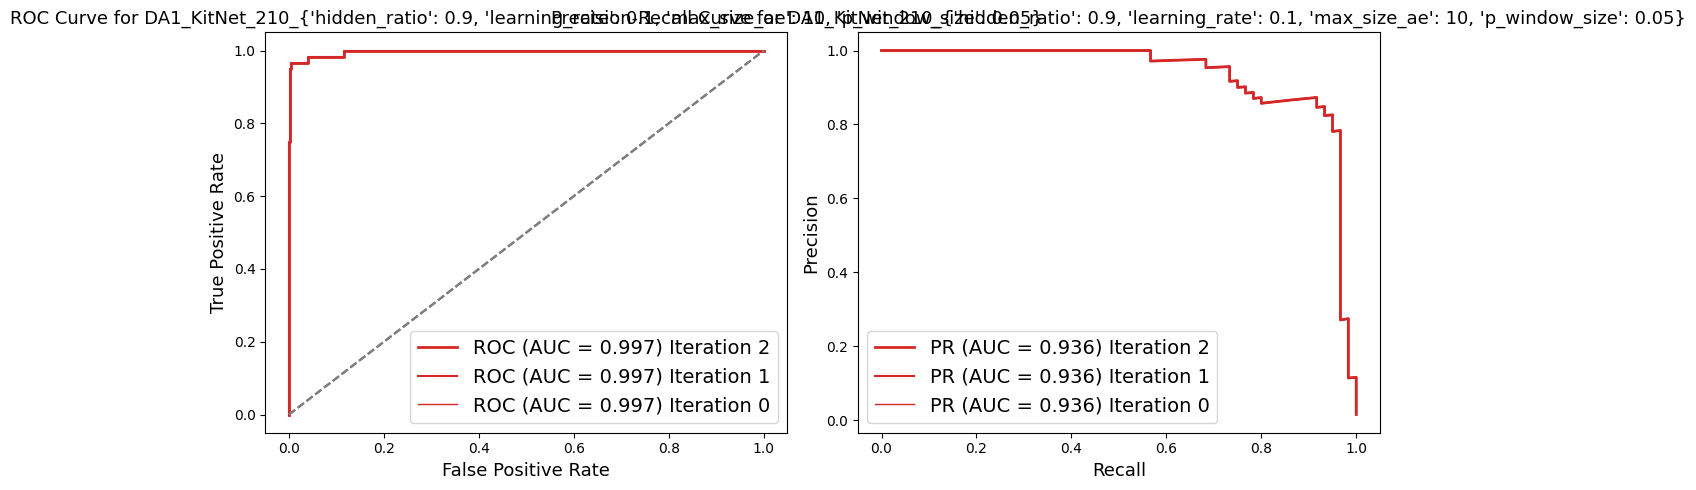

Method: DA1_IForestASD_840_{'initial_window_X': None, 'p_window_size': 0.2}, Iteration: 2
Method: DA1_IForestASD_840_{'initial_window_X': None, 'p_window_size': 0.2}, Iteration: 1
Method: DA1_IForestASD_840_{'initial_window_X': None, 'p_window_size': 0.2}, Iteration: 0


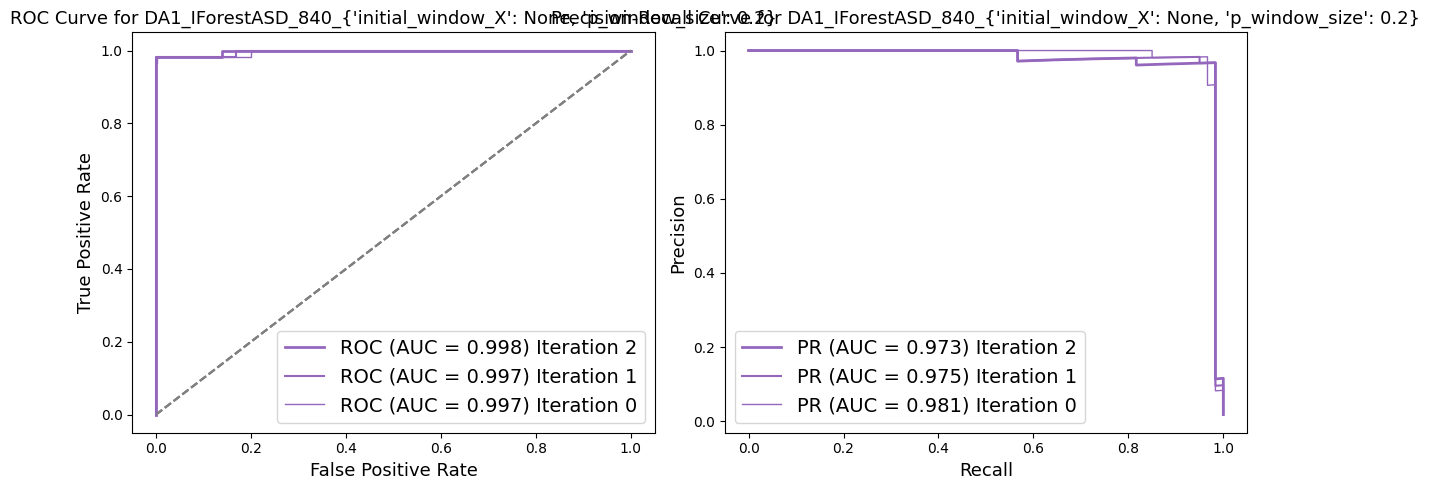

Method: DA1_oIF_840_{'growth_criterion': 'fixed', 'max_leaf_samples': 64, 'n_jobs': -1, 'num_trees': 64, 'p_window_size': 0.2}, Iteration: 0
Method: DA1_oIF_840_{'growth_criterion': 'fixed', 'max_leaf_samples': 64, 'n_jobs': -1, 'num_trees': 64, 'p_window_size': 0.2}, Iteration: 1
Method: DA1_oIF_840_{'growth_criterion': 'fixed', 'max_leaf_samples': 64, 'n_jobs': -1, 'num_trees': 64, 'p_window_size': 0.2}, Iteration: 2


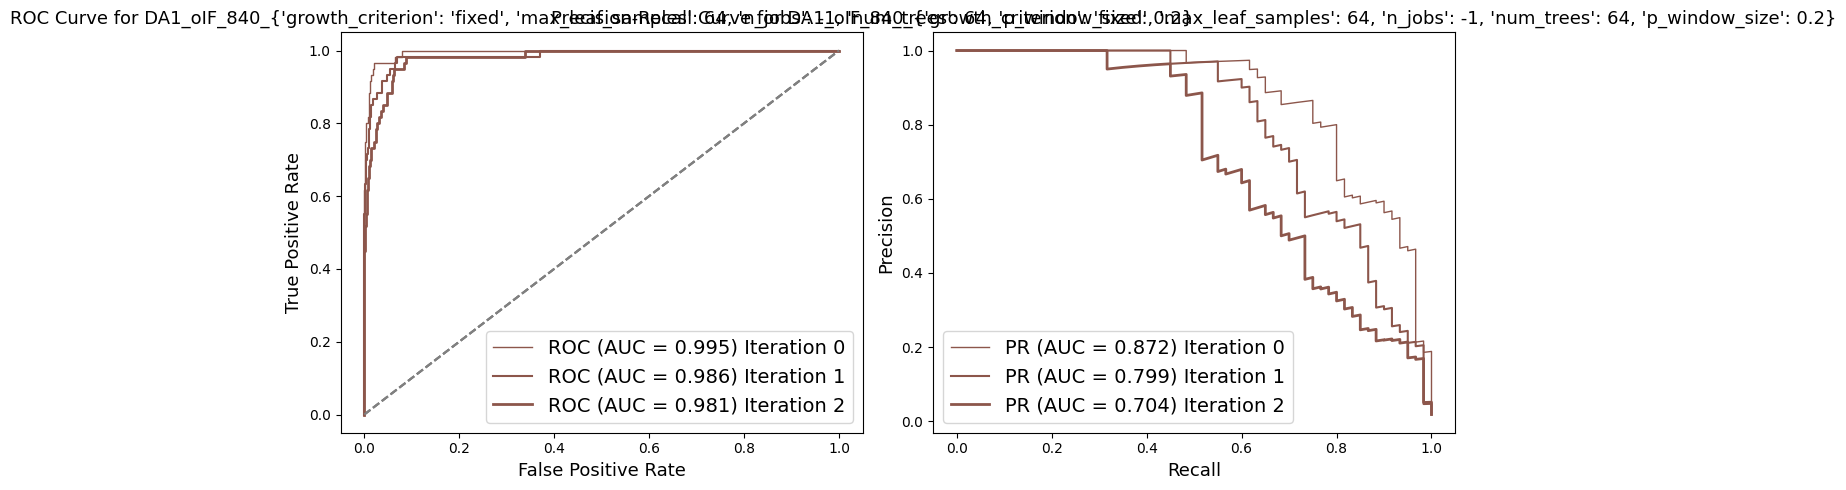

In [323]:

for m, color in zip(tecnique, color_list):
    # Plot ROC Curve
    plt.figure(figsize=(12, 5))
    f_method_data = final_df[final_df[acol] == m]
    
    for i in f_method_data['iteration'].unique():
        
        print(f"Method: {m}, Iteration: {i}")
        # Filter data for the current method and iteration
        method_data = f_method_data[f_method_data['iteration'] == i]
        
        N = len(method_data) - int(method_data['window_size'].iloc[0])
        # Apply the filter
        method_data = method_data.tail(N)

        # Get true labels and scores
        y_true = method_data['ground_truth'].values
        y_scores = method_data['cleaned_score'].values

        # Compute ROC curve and AUC
        fpr, tpr, _ = roc_curve(y_true, y_scores)
        roc_auc = auc(fpr, tpr)

        # Compute Precision-Recall curve and AUC
        precision, recall, _ = precision_recall_curve(y_true, y_scores)
        pr_auc = auc(recall, precision)



        plt.subplot(1, 2, 1)
        plt.plot(fpr, tpr, color=color, lw=1 + i * 0.5, label=f'ROC (AUC = {roc_auc:.3f}) Iteration {i}')


        plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
        plt.xlabel('False Positive Rate', fontsize=FONTSIZE_SEC)
        plt.ylabel('True Positive Rate', fontsize=FONTSIZE_SEC)
        plt.title(f'ROC Curve for {m}', fontsize=FONTSIZE_SEC)
        plt.legend(loc='lower right', fontsize=FONTSIZE_MAIN)

        # Plot Precision-Recall Curve
        plt.subplot(1, 2, 2)
        plt.plot(recall, precision, color=color, lw=1 + i * 0.5, label=f'PR (AUC = {pr_auc:.3f}) Iteration {i}')


        plt.xlabel('Recall', fontsize=FONTSIZE_SEC)
        plt.ylabel('Precision', fontsize=FONTSIZE_SEC)
        plt.title(f'Precision-Recall Curve for {m}', fontsize=FONTSIZE_SEC)
        plt.legend(loc='lower left', fontsize=FONTSIZE_MAIN)

        plt.tight_layout()
    plt.show()




## Individual Training Time of Online Anomaly Detectors with PV Datasets 

/tmp/ipykernel_1729744/1546120544.py:65: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


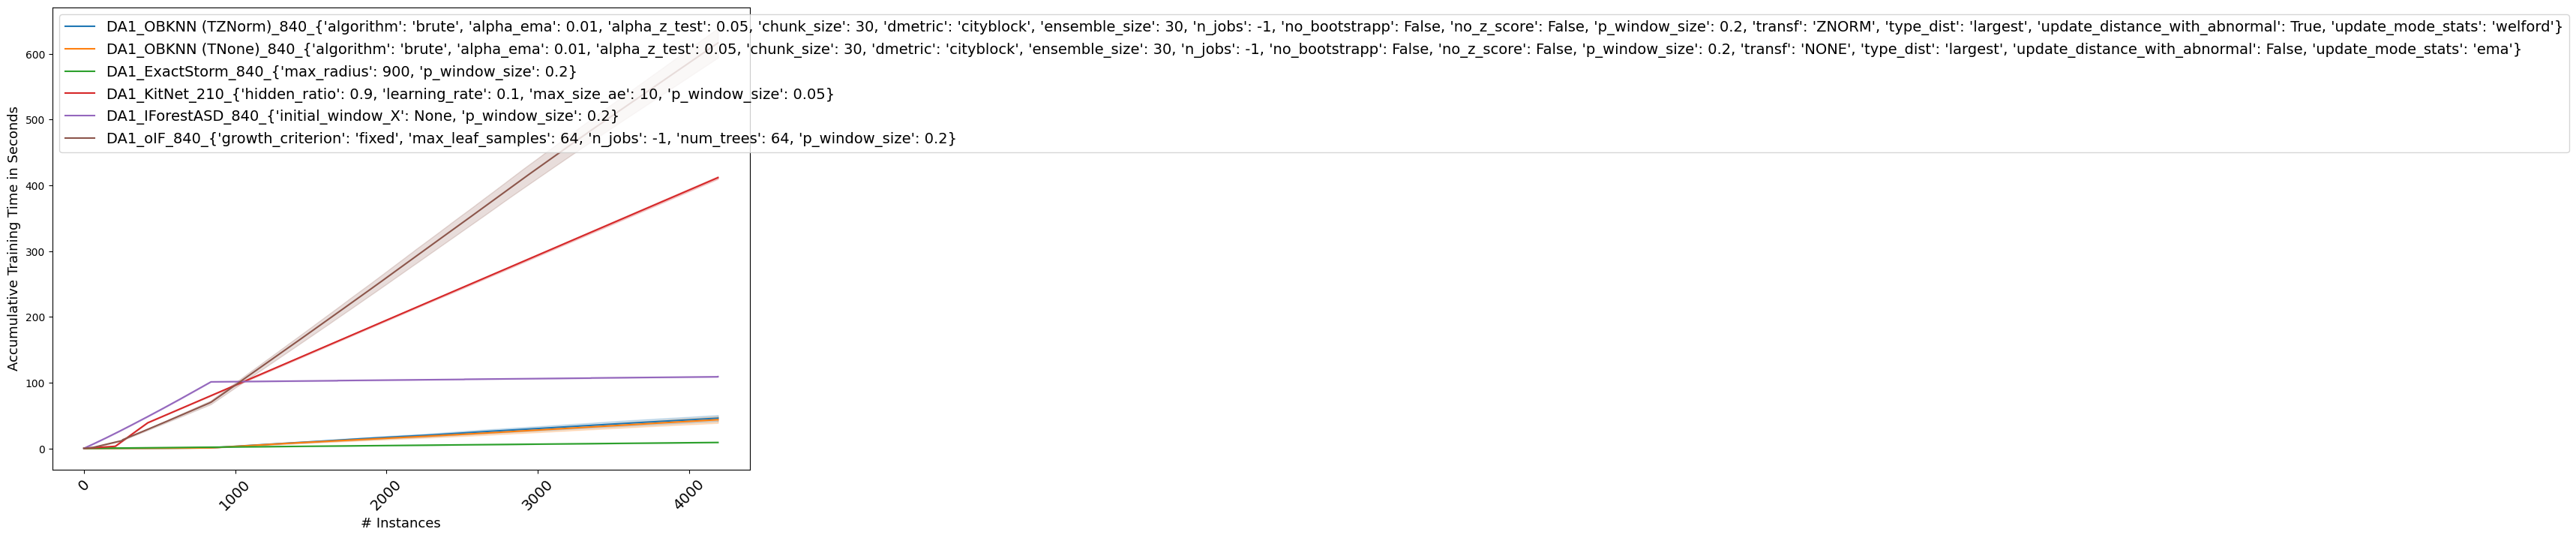

In [324]:
# Create a single figure
plt.figure(figsize=(12, 8))

# Group data by method and timestamp, calculating mean and standard deviation across iterations
grouped_data = final_df.groupby([acol, 'timestamp']).agg(
    mean_training_time_t=('training_time', 'mean'),
    std_training_time_t=('training_time', 'std')
).reset_index()

# Loop through methods and plot the accumulated values with shaded area
for m, color in zip(tecnique, color_list):
    
    method_data = grouped_data[grouped_data[acol] == m]

    # Compute cumulative sum
    cumulative_training_time = method_data['mean_training_time_t'].expanding().sum()

    # Plot averaged training time with accumulation
    plt.plot(
        range(len(method_data['timestamp'])),  # Use the index as x-axis
        cumulative_training_time,
        label=f'{m}',
        color=color
    )

    # Plot shaded area representing standard deviation
    plt.fill_between(
        range(len(method_data['timestamp'])),  # Use the index as x-axis
        (method_data['mean_training_time_t'] - method_data['std_training_time_t']).expanding().sum(),
        (method_data['mean_training_time_t'] + method_data['std_training_time_t']).expanding().sum(),
        color=color,
        alpha=0.2
    )

    # Get max accumulated training time and timestamp
    max_time = cumulative_training_time.max()

    max_timestamp = len(method_data['timestamp'])  # Ensuring correct index

    # Format the max value properly
    formatted_max_time = f"{max_time:,.2f}"  # Adds commas and rounds to 2 decimals

    if m in ["OnlineBootKNN", "xStream", "KitNet"]:
        # Annotate the max value
        plt.annotate(
            f'Max: {formatted_max_time}', 
            xy=(max_timestamp, max_time), 
            xytext=(max_timestamp, max_time * 1.03),  # Adjusted for better visibility
            #arrowprops=dict(facecolor=color, arrowstyle='->'),
            fontsize=FONTSIZE_MAIN,
            color=color,
            ha='center'
        )

# Format the x-axis to show only the hours
# plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    
# Adding labels and title
#plt.title("Training Time", fontsize=FONTSIZE_SEC)
plt.xlabel('# Instances', fontsize=FONTSIZE_SEC)
plt.ylabel('Accumulative Training Time in Seconds', fontsize=FONTSIZE_SEC)
plt.legend(loc='upper left', fontsize=FONTSIZE_MAIN)  # Place legend dynamically
plt.xticks(rotation=45, fontsize=FONTSIZE_MAIN)
#plt.grid(True, linestyle='--', alpha=0.6)  # Improve grid visibility
plt.tight_layout()

#plt.savefig(current_dir / 'notebooks' / 'img_training_and_scoring_time'/f"{SCENARIO}_accum_training_time.pdf", format="pdf")
# Display the plot
plt.show()


/tmp/ipykernel_1729744/3073698684.py:62: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


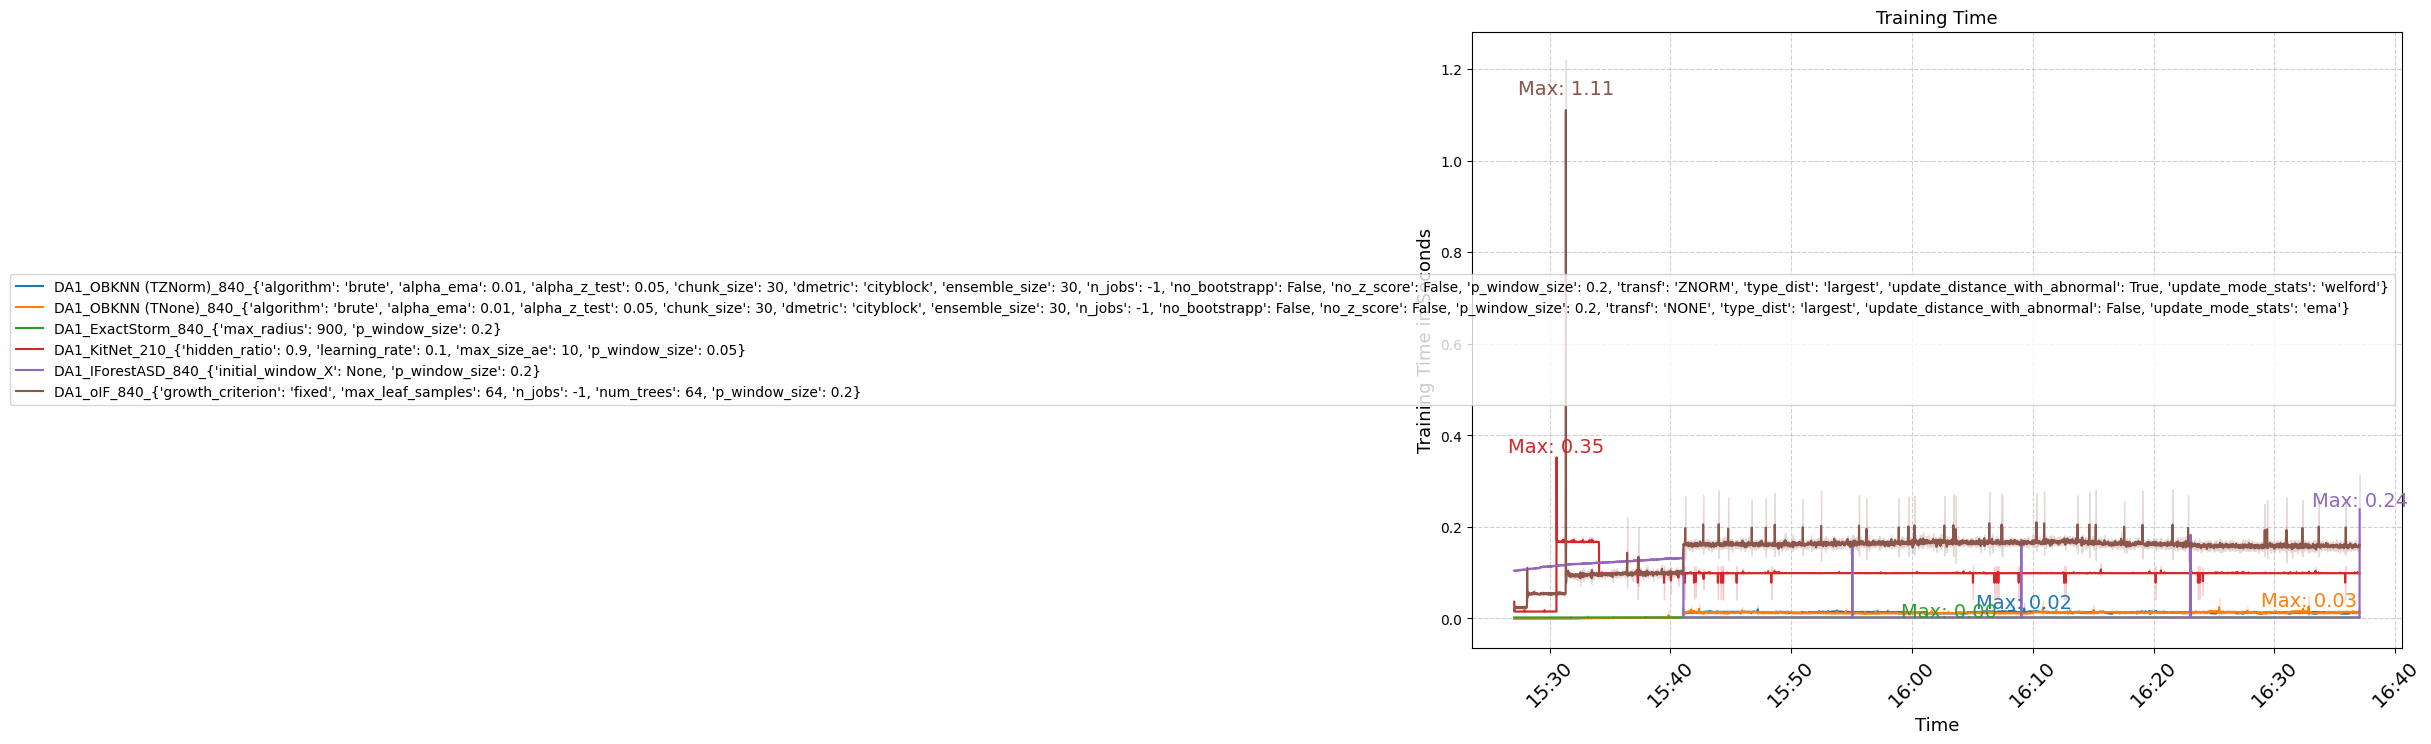

In [325]:
# Create a single figure
plt.figure(figsize=(12, 8))

# Group data by method and timestamp, calculating mean and standard deviation across iterations
grouped_data = final_df.groupby([acol, 'timestamp']).agg(
    mean_training_time_t=('training_time', 'mean'),
    std_training_time_t=('training_time', 'std')
).reset_index()


for m, color in zip(tecnique, color_list):
    
    method_data = grouped_data[grouped_data[acol] == m]

    
    training_time = method_data['mean_training_time_t']

    # Plot averaged training time 
    plt.plot(
        method_data['timestamp'],
        training_time,
        label=f'{m}',
        color=color
    )

    # Plot shaded area representing standard deviation
    plt.fill_between(
        method_data['timestamp'],
        (method_data['mean_training_time_t'] - method_data['std_training_time_t']),
        (method_data['mean_training_time_t'] + method_data['std_training_time_t']),
        color=color,
        alpha=0.2
    )

    
    max_time = training_time.max()
    max_idx = training_time.idxmax()
    max_timestamp = method_data.loc[max_idx, 'timestamp']  # Ensuring correct index

    # Format the max value properly
    formatted_max_time = f"{max_time:,.2f}"  # Adds commas and rounds to 2 decimals

    # Annotate the max value
    plt.annotate(
        f'Max: {formatted_max_time}', 
        xy=(max_timestamp, max_time), 
        xytext=(max_timestamp, max_time * 1.03),  # Adjusted for better visibility
        #arrowprops=dict(facecolor=color, arrowstyle='->'),
        fontsize=FONTSIZE_MAIN,
        color=color,
        ha='center'
    )
# Format the x-axis to show only the hours
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
# Adding labels and title
plt.xlabel('Time', fontsize=FONTSIZE_SEC)
plt.ylabel('Training Time in Seconds', fontsize=FONTSIZE_SEC)
plt.legend(loc='best')  # Place legend dynamically
plt.title("Training Time", fontsize=FONTSIZE_SEC)
plt.xticks(rotation=45, fontsize=FONTSIZE_MAIN)
plt.grid(True, linestyle='--', alpha=0.6)  # Improve grid visibility
plt.tight_layout()

#plt.savefig(f"/home/nicolas/spectral_anomaly_detector/notebooks/img_training_and_scoring_time/{SCENARIO}_training_time.png", format="png")
# Display the plot
plt.show()


In [326]:
# Group by method and compute training time statistics
training_time_stats = final_df.groupby([acol, 'timestamp'])['training_time'].agg(
    mean_training_time_t='mean',
).reset_index()

training_time_stats = training_time_stats.groupby([acol])['mean_training_time_t'].agg(
    mean_time='mean',
    #median_time='median',
    min_time='min',
    max_time='max',
    std_dev_time='std'
).reset_index()

# Sort by mean training time in ascending order
training_time_stats = training_time_stats.sort_values(by='mean_time', ascending=False)

# Display summary
training_time_stats

,scenario_method_window_and_param,mean_time,min_time,max_time,std_dev_time
5,"DA1_oIF_840_{'growth_criterion': 'fixed', 'max_leaf_samples': 64, 'n_jobs': -1, 'num_trees': 64, 'p_window_size': 0.2}",0.147092,0.015919,1.110775,0.037686
2,"DA1_KitNet_210_{'hidden_ratio': 0.9, 'learning_rate': 0.1, 'max_size_ae': 10, 'p_window_size': 0.05}",0.098221,0.015097,0.351923,0.024561
1,"DA1_IForestASD_840_{'initial_window_X': None, 'p_window_size': 0.2}",0.026028,0.002098,0.238482,0.047785
4,"DA1_OBKNN (TZNorm)_840_{'algorithm': 'brute', 'alpha_ema': 0.01, 'alpha_z_test': 0.05, 'chunk_size': 30, 'dmetric': 'cityblock', 'ensemble_size': 30, 'n_jobs': -1, 'no_bootstrapp': False, 'no_z_score': False, 'p_window_size': 0.2, 'transf': 'ZNORM', 'type_dist': 'largest', 'update_distance_with_abnormal': True, 'update_mode_stats': 'welford'}",0.010948,0.000159,0.021942,0.005043
3,"DA1_OBKNN (TNone)_840_{'algorithm': 'brute', 'alpha_ema': 0.01, 'alpha_z_test': 0.05, 'chunk_size': 30, 'dmetric': 'cityblock', 'ensemble_size': 30, 'n_jobs': -1, 'no_bootstrapp': False, 'no_z_score': False, 'p_window_size': 0.2, 'transf': 'NONE', 'type_dist': 'largest', 'update_distance_with_abnormal': False, 'update_mode_stats': 'ema'}",0.010408,0.000013,0.025997,0.004886
0,"DA1_ExactStorm_840_{'max_radius': 900, 'p_window_size': 0.2}",0.002144,0.002093,0.002541,0.000018


## Individual Scoring Time of Online Anomaly Detectors with PV Datasets 

/tmp/ipykernel_1729744/1803769941.py:65: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


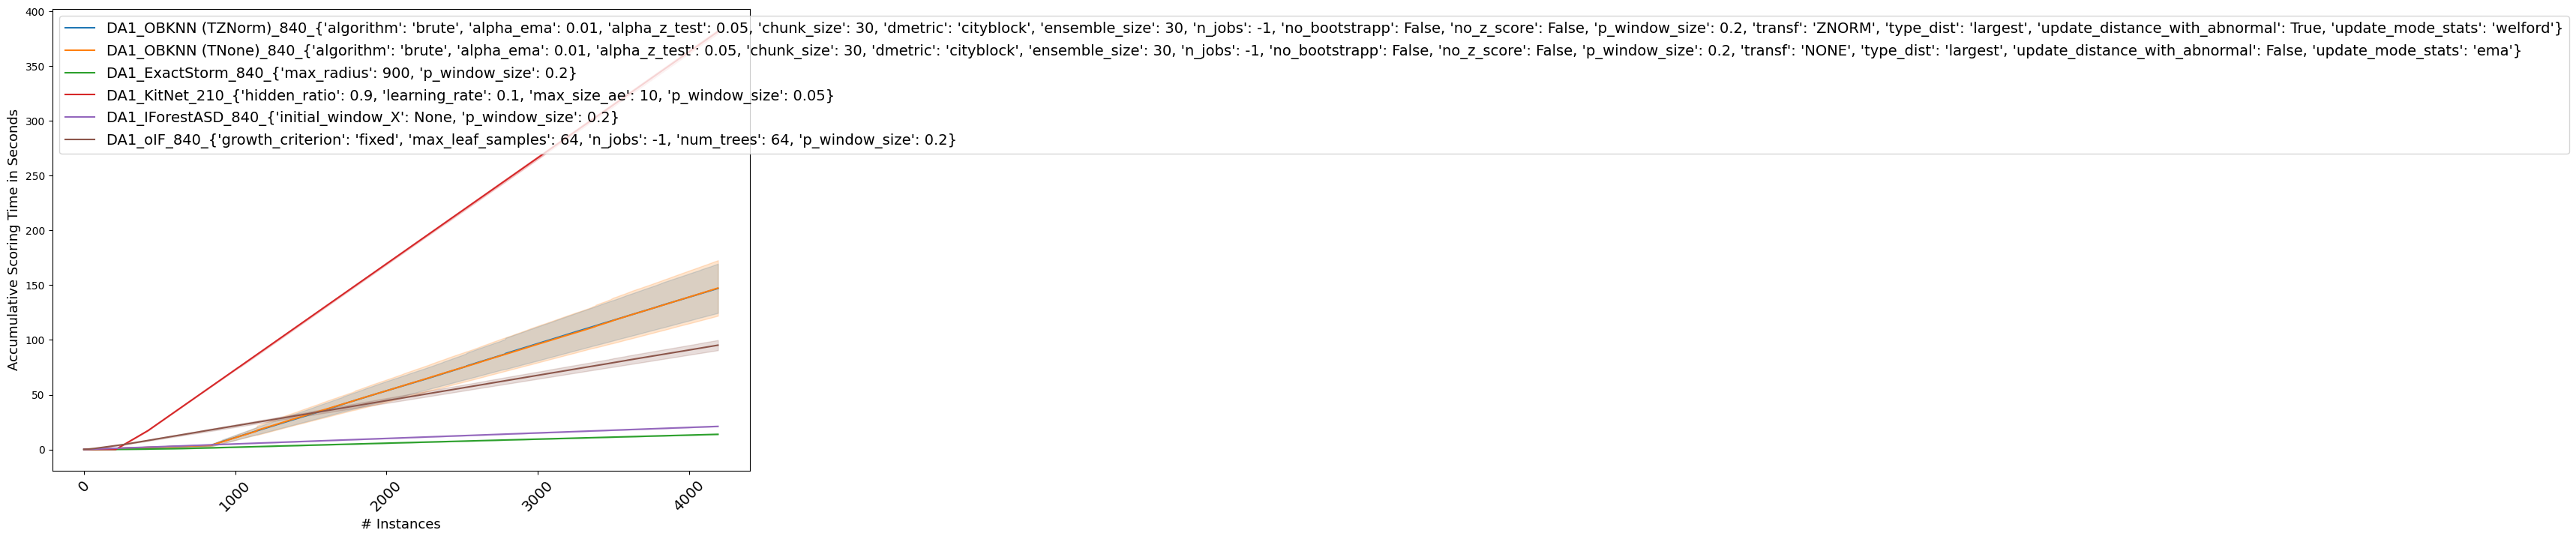

In [327]:
# Create a single figure
plt.figure(figsize=(12, 8))

# Group data by method and timestamp, calculating mean and standard deviation across iterations
grouped_data = final_df.groupby([acol, 'timestamp']).agg(
    mean_scoring_time_t=('scoring_time', 'mean'),
    std_scoring_time_t=('scoring_time', 'std')
).reset_index()

# Loop through methods and plot the accumulated values with shaded area
for m, color in zip(tecnique, color_list):
    
    method_data = grouped_data[grouped_data[acol] == m]

    # Compute cumulative sum
    cumulative_training_time = method_data['mean_scoring_time_t'].expanding().sum()

    # Plot averaged training time with accumulation
    plt.plot(
        range(len(method_data['timestamp'])),  # Use the index as x-axis
        cumulative_training_time,
        label=f'{m}',
        color=color
    )

    # Plot shaded area representing standard deviation
    plt.fill_between(
        range(len(method_data['timestamp'])),  # Use the index as x-axis
        (method_data['mean_scoring_time_t'] - method_data['std_scoring_time_t']).expanding().sum(),
        (method_data['mean_scoring_time_t'] + method_data['std_scoring_time_t']).expanding().sum(),
        color=color,
        alpha=0.2
    )

    # Get max accumulated training time and timestamp
    max_time = cumulative_training_time.max()

    max_timestamp = len(method_data['timestamp'])  # Ensuring correct index

    # Format the max value properly
    formatted_max_time = f"{max_time:,.2f}"  # Adds commas and rounds to 2 decimals

    if m in ["OnlineBootKNN", "xStream", "KitNet"]:
        # Annotate the max value
        plt.annotate(
            f'Max: {formatted_max_time}', 
            xy=(max_timestamp, max_time), 
            xytext=(max_timestamp, max_time * 1.03),  # Adjusted for better visibility
            #arrowprops=dict(facecolor=color, arrowstyle='->'),
            fontsize=FONTSIZE_MAIN,
            color=color,
            ha='center'
        )

# Format the x-axis to show only the hours
# plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    
# Adding labels and title
#plt.title("Scoring Time", fontsize=FONTSIZE_SEC)
plt.xlabel('# Instances', fontsize=FONTSIZE_SEC)
plt.ylabel('Accumulative Scoring Time in Seconds', fontsize=FONTSIZE_SEC)
plt.legend(loc='upper left', fontsize=FONTSIZE_MAIN)  # Place legend dynamically
plt.xticks(rotation=45, fontsize=FONTSIZE_MAIN)
#plt.grid(True, linestyle='--', alpha=0.6)  # Improve grid visibility
plt.tight_layout()
#plt.savefig(current_dir / 'notebooks' / 'img_training_and_scoring_time'/ f"{SCENARIO}_accum_scoring_time.pdf", format="pdf")
# Display the plot
plt.show()


/tmp/ipykernel_1729744/1897660736.py:59: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


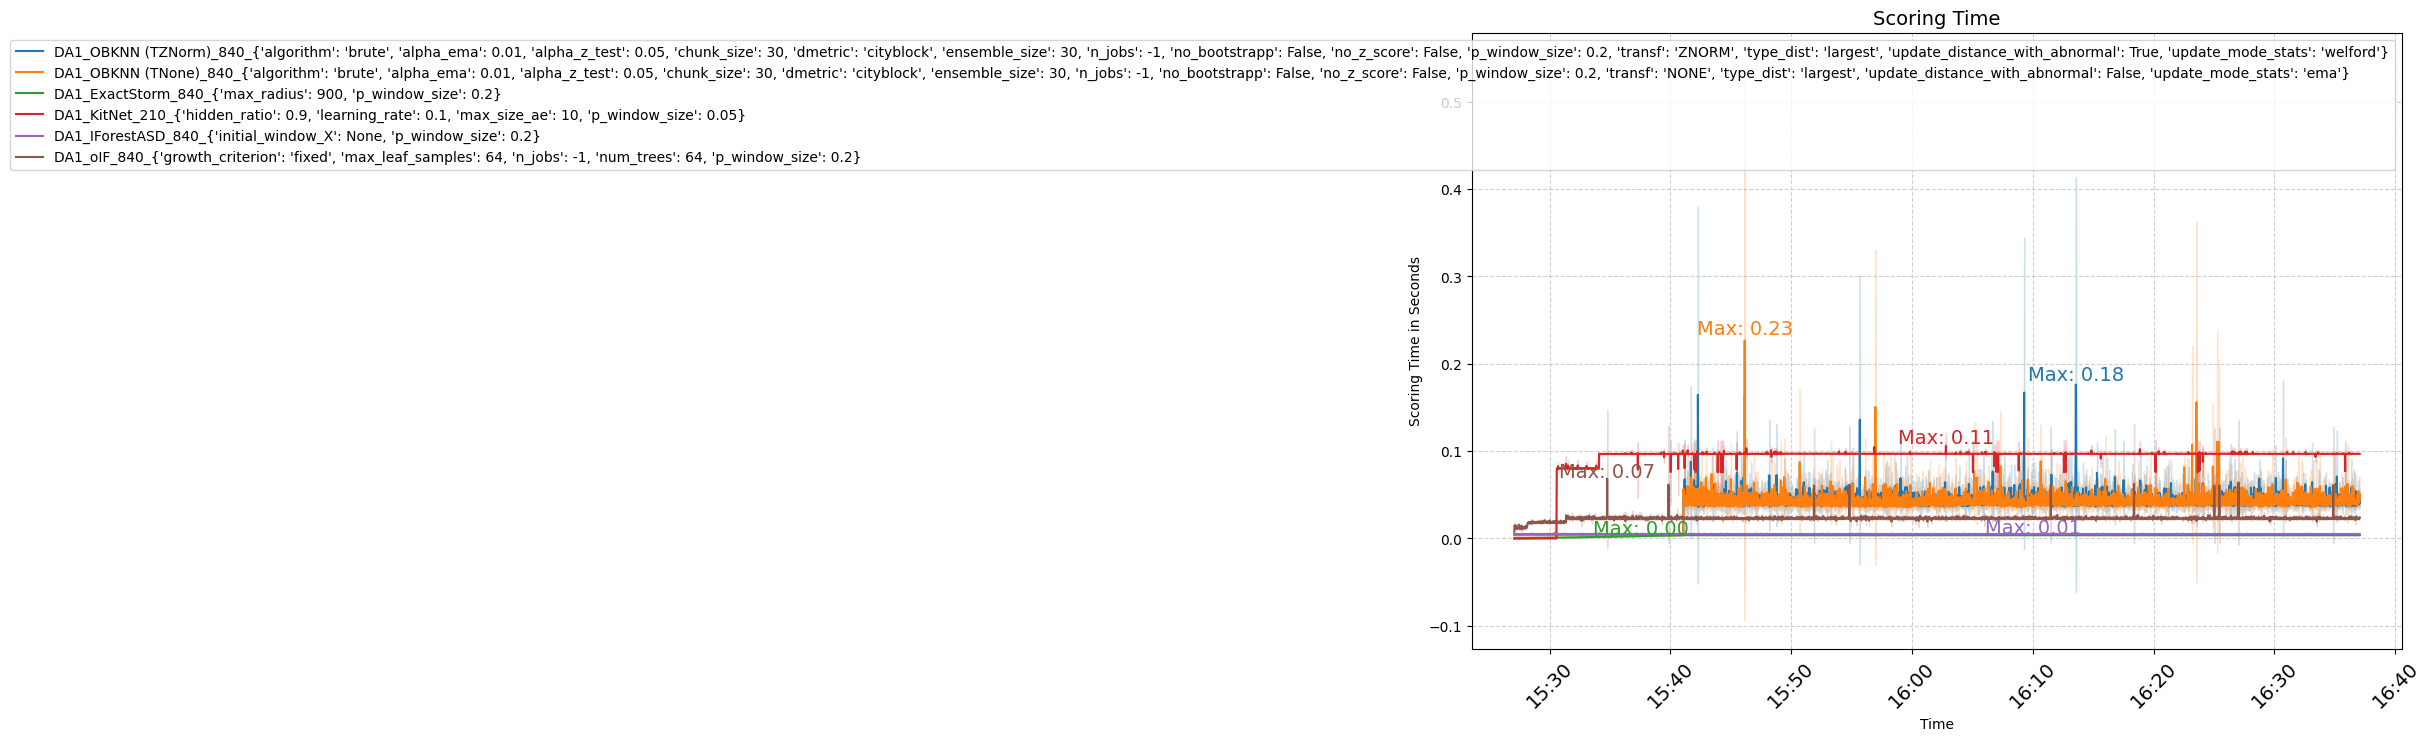

In [328]:
# Create a single figure
plt.figure(figsize=(12, 8))

# Group data by method and timestamp, calculating mean and standard deviation across iterations
grouped_data = final_df.groupby([acol, 'timestamp']).agg(
    mean_scoring_time_t=('scoring_time', 'mean'),
    std_scoring_time_t=('scoring_time', 'std')
).reset_index()


for m, color in zip(tecnique, color_list):
    
    method_data = grouped_data[grouped_data[acol] == m]

    scoring_time = method_data['mean_scoring_time_t']

    plt.plot(
        method_data['timestamp'],
        scoring_time,
        label=f'{m}',
        color=color
    )

    # Plot shaded area representing standard deviation
    plt.fill_between(
        method_data['timestamp'],
        (method_data['mean_scoring_time_t'] - method_data['std_scoring_time_t']),
        (method_data['mean_scoring_time_t'] + method_data['std_scoring_time_t']),
        color=color,
        alpha=0.2
    )

    
    max_time = scoring_time.max()
    max_idx = scoring_time.idxmax()
    max_timestamp = method_data.loc[max_idx, 'timestamp']  # Ensuring correct index

    # Format the max value properly
    formatted_max_time = f"{max_time:,.2f}"  # Adds commas and rounds to 2 decimals

    # Annotate the max value
    plt.annotate(
        f'Max: {formatted_max_time}', 
        xy=(max_timestamp, max_time), 
        xytext=(max_timestamp, max_time * 1.03),  # Adjusted for better visibility
        #arrowprops=dict(facecolor=color, arrowstyle='->'),
        fontsize=FONTSIZE_MAIN,
        color=color,
        ha='center'
    )
# Format the x-axis to show only the hours
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
# Adding labels and title
plt.xlabel('Time')
plt.ylabel('Scoring Time in Seconds')
plt.legend(loc='best')  # Place legend dynamically
plt.xticks(rotation=45, fontsize=FONTSIZE_MAIN)
plt.grid(True, linestyle='--', alpha=0.6)  # Improve grid visibility
plt.tight_layout()
plt.title("Scoring Time", fontsize=FONTSIZE_MAIN)
#plt.savefig(f"/home/nicolas/spectral_anomaly_detector/notebooks/img_training_and_scoring_time/{SCENARIO}_scoring_time.png", format="png")
# Display the plot
plt.show()


In [329]:
# Group by method and compute scoring time statistics
scoring_time_stats = final_df.groupby([acol, 'timestamp'])['scoring_time'].agg(
    mean_scoring_time_t='mean',
).reset_index()

scoring_time_stats = scoring_time_stats.groupby([acol])['mean_scoring_time_t'].agg(
    mean_time='mean',
    #median_time='median',
    min_time='min',
    max_time='max',
    std_dev_time='std'
).reset_index()

# Sort by mean scoring time in ascending order
scoring_time_stats = scoring_time_stats.sort_values(by='mean_time', ascending=False)

# Display summary
scoring_time_stats

,scenario_method_window_and_param,mean_time,min_time,max_time,std_dev_time
2,"DA1_KitNet_210_{'hidden_ratio': 0.9, 'learning_rate': 0.1, 'max_size_ae': 10, 'p_window_size': 0.05}",0.091025,0.000004,0.105790,0.021294
3,"DA1_OBKNN (TNone)_840_{'algorithm': 'brute', 'alpha_ema': 0.01, 'alpha_z_test': 0.05, 'chunk_size': 30, 'dmetric': 'cityblock', 'ensemble_size': 30, 'n_jobs': -1, 'no_bootstrapp': False, 'no_z_score': False, 'p_window_size': 0.2, 'transf': 'NONE', 'type_dist': 'largest', 'update_distance_with_abnormal': False, 'update_mode_stats': 'ema'}",0.035159,0.004199,0.226382,0.017117
4,"DA1_OBKNN (TZNorm)_840_{'algorithm': 'brute', 'alpha_ema': 0.01, 'alpha_z_test': 0.05, 'chunk_size': 30, 'dmetric': 'cityblock', 'ensemble_size': 30, 'n_jobs': -1, 'no_bootstrapp': False, 'no_z_score': False, 'p_window_size': 0.2, 'transf': 'ZNORM', 'type_dist': 'largest', 'update_distance_with_abnormal': True, 'update_mode_stats': 'welford'}",0.035083,0.004201,0.176087,0.016735
5,"DA1_oIF_840_{'growth_criterion': 'fixed', 'max_leaf_samples': 64, 'n_jobs': -1, 'num_trees': 64, 'p_window_size': 0.2}",0.022713,0.007824,0.068358,0.002615
1,"DA1_IForestASD_840_{'initial_window_X': None, 'p_window_size': 0.2}",0.005026,0.004977,0.005518,0.000059
0,"DA1_ExactStorm_840_{'max_radius': 900, 'p_window_size': 0.2}",0.003299,0.000003,0.004096,0.000911


In [330]:
final_df['total_time']=final_df['training_time']+final_df['scoring_time']

/tmp/ipykernel_1729744/1104649029.py:76: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


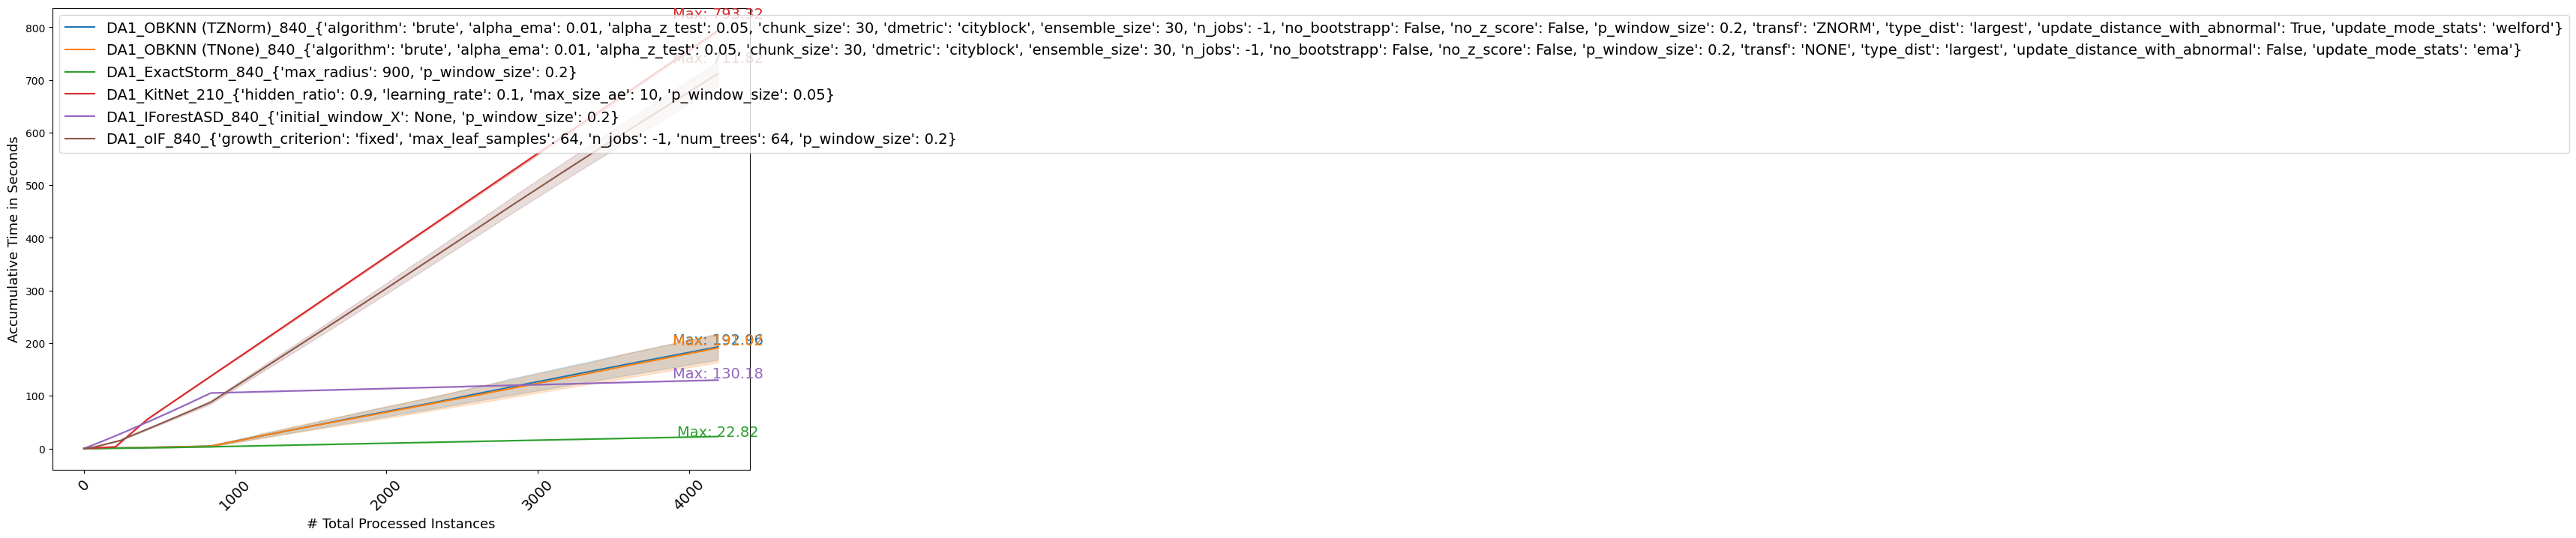

In [331]:
# Create a single figure
plt.figure(figsize=(12, 8))

# Group data by method and timestamp, calculating mean and standard deviation across iterations
grouped_data = final_df.groupby([acol, 'timestamp']).agg(
    mean_total_time_t=('total_time', 'mean'),
    std_total_time_t=('total_time', 'std')
).reset_index()

# Loop through methods and plot the accumulated values with shaded area
for m, color in zip(tecnique, color_list):
    
    method_data = grouped_data[grouped_data[acol] == m]

    # Compute cumulative sum
    cumulative_training_time = method_data['mean_total_time_t'].expanding().sum()

    # Plot averaged training time with accumulation
    plt.plot(
        range(len(method_data['timestamp'])),  # Use the index as x-axis
        cumulative_training_time,
        label=f'{m}',
        color=color
    )

    # Plot shaded area representing standard deviation
    plt.fill_between(
        range(len(method_data['timestamp'])),  # Use the index as x-axis
        (method_data['mean_total_time_t'] - method_data['std_total_time_t']).expanding().sum(),
        (method_data['mean_total_time_t'] + method_data['std_total_time_t']).expanding().sum(),
        color=color,
        alpha=0.2
    )

    # Get max accumulated training time and timestamp
    max_time = cumulative_training_time.max()

    max_timestamp = len(method_data['timestamp'])  # Ensuring correct index

    # Format the max value properly
    formatted_max_time = f"{max_time:,.2f}"  # Adds commas and rounds to 2 decimals
    """
    if m in ["OnlineBootKNN", "xStream", "KitNet"]:
        # Annotate the max value
        plt.annotate(
            f'Max: {formatted_max_time}', 
            xy=(max_timestamp, max_time), 
            xytext=(max_timestamp, max_time * 1.03),  # Adjusted for better visibility
            #arrowprops=dict(facecolor=color, arrowstyle='->'),
            fontsize=FONTSIZE_MAIN,
            color=color,
            ha='center'
        )
    """
    # Annotate the max value
    plt.annotate(
            f'Max: {formatted_max_time}', 
            xy=(max_timestamp, max_time), 
            xytext=(max_timestamp, max_time * 1.03),  # Adjusted for better visibility
            #arrowprops=dict(facecolor=color, arrowstyle='->'),
            fontsize=FONTSIZE_MAIN,
            color=color,
            ha='center'
        )

# Format the x-axis to show only the hours
# plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    
# Adding labels and title
#plt.title("Scoring Time", fontsize=FONTSIZE_SEC)
plt.xlabel('# Total Processed Instances', fontsize=FONTSIZE_SEC)
plt.ylabel('Accumulative Time in Seconds', fontsize=FONTSIZE_SEC)
plt.legend(loc='upper left', fontsize=FONTSIZE_MAIN)  # Place legend dynamically
plt.xticks(rotation=45, fontsize=FONTSIZE_MAIN)
#plt.grid(True, linestyle='--', alpha=0.6)  # Improve grid visibility
plt.tight_layout()

#plt.savefig(current_dir / 'notebooks' / 'img_training_and_scoring_time'/f"{SCENARIO}_accum_total_time.pdf", format="pdf")
# Display the plot
plt.show()


In [332]:
# Group by method and compute scoring time statistics
total_time_stats = final_df.groupby(["param", 'timestamp'])['total_time'].agg(
    mean_total_time='mean',
).reset_index()

total_time_stats = total_time_stats.groupby(["param"])['mean_total_time'].agg(
    mean_time='mean',
    #median_time='median',
    min_time='min',
    max_time='max',
    std_dev_time='std'
).reset_index()

# Sort by mean scoring time in ascending order
total_time_stats = total_time_stats.sort_values(by='mean_time', ascending=False)

# Display summary
total_time_stats[["param","mean_time"]]

,param,mean_time
3,"{'hidden_ratio': 0.9, 'learning_rate': 0.1, 'max_size_ae': 10, 'p_window_size': 0.05}",0.189246
2,"{'growth_criterion': 'fixed', 'max_leaf_samples': 64, 'n_jobs': -1, 'num_trees': 64, 'p_window_size': 0.2}",0.169805
1,"{'algorithm': 'brute', 'alpha_ema': 0.01, 'alpha_z_test': 0.05, 'chunk_size': 30, 'dmetric': 'cityblock', 'ensemble_size': 30, 'n_jobs': -1, 'no_bootstrapp': False, 'no_z_score': False, 'p_window_size': 0.2, 'transf': 'ZNORM', 'type_dist': 'largest', 'update_distance_with_abnormal': True, 'update_mode_stats': 'welford'}",0.046031
0,"{'algorithm': 'brute', 'alpha_ema': 0.01, 'alpha_z_test': 0.05, 'chunk_size': 30, 'dmetric': 'cityblock', 'ensemble_size': 30, 'n_jobs': -1, 'no_bootstrapp': False, 'no_z_score': False, 'p_window_size': 0.2, 'transf': 'NONE', 'type_dist': 'largest', 'update_distance_with_abnormal': False, 'update_mode_stats': 'ema'}",0.045567
4,"{'initial_window_X': None, 'p_window_size': 0.2}",0.031053
5,"{'max_radius': 900, 'p_window_size': 0.2}",0.005443


# Analysis mDragstream

## Euclidean Distance

In [333]:
euclidean_mdragstream = df[df['method_window_and_param'].str.contains("'metric': 'euclidean'", na=False)]
euclidean_mdragstream.params_with_p_window_size.unique()

array([], dtype=object)

In [334]:
euclidean_mdragstream.loc[:, 'total_time'] = (
    euclidean_mdragstream['training_time'] + euclidean_mdragstream['scoring_time']
)
scenario_method_window_and_param = euclidean_mdragstream["scenario_method_window_and_param"].unique()
tecnique = scenario_method_window_and_param
color_list = [colors[i] for i in range(len(tecnique))]

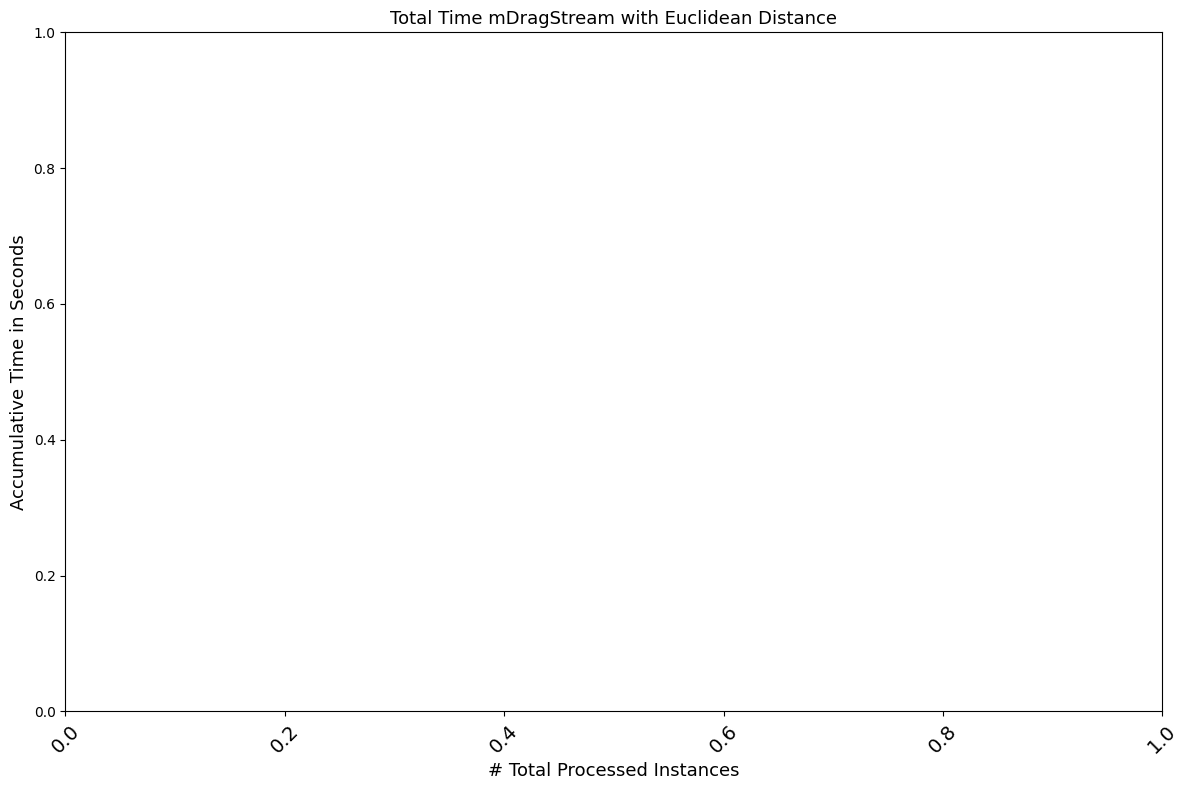

In [335]:
# Create a single figure
plt.figure(figsize=(12, 8))

# Group data by method and timestamp, calculating mean and standard deviation across iterations
grouped_data = euclidean_mdragstream.groupby([acol, 'timestamp']).agg(
    mean_total_time_t=('total_time', 'mean'),
    std_total_time_t=('total_time', 'std')
).reset_index()
grouped_data['std_total_time_t'] = grouped_data['std_total_time_t'].fillna(0)
# Loop through methods and plot the accumulated values with shaded area
for m, color in zip(tecnique, color_list):
    
    method_data = grouped_data[grouped_data[acol] == m]

    # Compute cumulative sum
    cumulative_training_time = method_data['mean_total_time_t'].expanding().sum()

    # Plot averaged training time with accumulation
    plt.plot(
        range(len(method_data['timestamp'])),  # Use the index as x-axis
        cumulative_training_time,
        label=f'{m}',
        color=color
    )

    # Plot shaded area representing standard deviation
    plt.fill_between(
        range(len(method_data['timestamp'])),  # Use the index as x-axis
        (method_data['mean_total_time_t'] - method_data['std_total_time_t']).expanding().sum(),
        (method_data['mean_total_time_t'] + method_data['std_total_time_t']).expanding().sum(),
        color=color,
        alpha=0.2
    )

    # Get max accumulated training time and timestamp
    max_time = cumulative_training_time.max()

    max_timestamp = len(method_data['timestamp'])  # Ensuring correct index

    # Format the max value properly
    formatted_max_time = f"{max_time:,.2f}"  # Adds commas and rounds to 2 decimals
    """
    if m in ["OnlineBootKNN", "xStream", "KitNet"]:
        # Annotate the max value
        plt.annotate(
            f'Max: {formatted_max_time}', 
            xy=(max_timestamp, max_time), 
            xytext=(max_timestamp, max_time * 1.03),  # Adjusted for better visibility
            #arrowprops=dict(facecolor=color, arrowstyle='->'),
            fontsize=FONTSIZE_MAIN,
            color=color,
            ha='center'
        )
    """
    # Annotate the max value
    plt.annotate(
            f'Max: {formatted_max_time}', 
            xy=(max_timestamp, max_time), 
            xytext=(max_timestamp, max_time * 1.03),  # Adjusted for better visibility
            #arrowprops=dict(facecolor=color, arrowstyle='->'),
            fontsize=FONTSIZE_MAIN,
            color=color,
            ha='center'
        )

# Format the x-axis to show only the hours
# plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    
# Adding labels and title
plt.title("Total Time mDragStream with Euclidean Distance", fontsize=FONTSIZE_SEC)
plt.xlabel('# Total Processed Instances', fontsize=FONTSIZE_SEC)
plt.ylabel('Accumulative Time in Seconds', fontsize=FONTSIZE_SEC)
plt.ylim(0,)
#plt.legend(loc='upper left', fontsize=FONTSIZE_MAIN)  # Place legend dynamically
plt.xticks(rotation=45, fontsize=FONTSIZE_MAIN)
#plt.grid(True, linestyle='--', alpha=0.6)  # Improve grid visibility
plt.tight_layout()

#plt.savefig(current_dir / 'notebooks' / 'img_training_and_scoring_time'/f"{SCENARIO}_accum_total_time.pdf", format="pdf")
# Display the plot
plt.show()


In [336]:

total_time_stats = euclidean_mdragstream.groupby([acol, 'timestamp'])['total_time'].agg(
    mean_total_time='mean'
).reset_index()


total_time_stats['sum_total_time'] = total_time_stats.groupby(acol)['mean_total_time'].cumsum()


summary = total_time_stats.groupby(acol)['sum_total_time'].agg(
    max_total_time='max' # The last point of the cumulative sum is the total
).reset_index()
summary.sort_values(by='max_total_time', ascending=False)

,scenario_method_window_and_param,max_total_time


## Mahalanobis Distance

In [337]:
mahalanobis_mdragstream = df[df['method_window_and_param'].str.contains("'metric': 'mahalanobis'", na=False)]
mahalanobis_mdragstream.params_with_p_window_size.unique()

array([], dtype=object)

In [338]:
mahalanobis_mdragstream.loc[:, 'total_time'] = (
    mahalanobis_mdragstream['training_time'] + mahalanobis_mdragstream['scoring_time']
)
scenario_method_window_and_param = mahalanobis_mdragstream["scenario_method_window_and_param"].unique()
tecnique = scenario_method_window_and_param
color_list = [colors[i] for i in range(len(tecnique))]

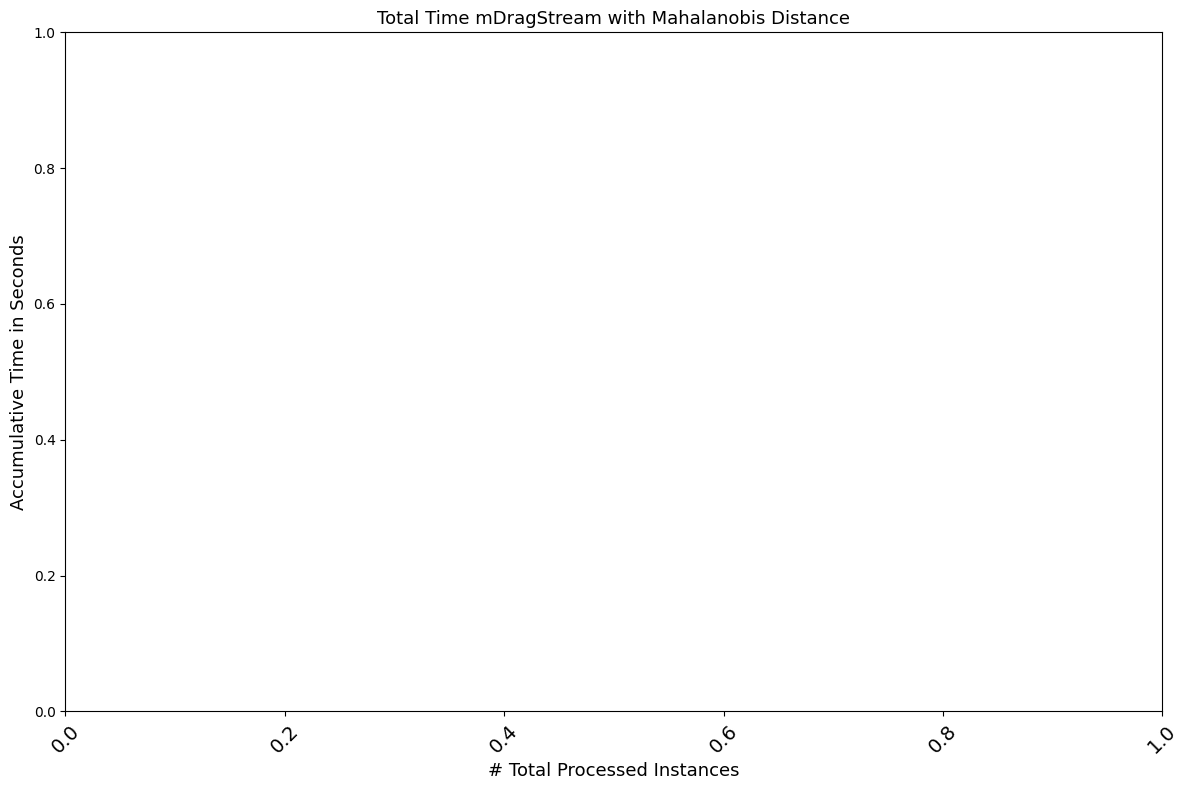

In [339]:
# Create a single figure
plt.figure(figsize=(12, 8))

# Group data by method and timestamp, calculating mean and standard deviation across iterations
grouped_data = mahalanobis_mdragstream.groupby([acol, 'timestamp']).agg(
    mean_total_time_t=('total_time', 'mean'),
    std_total_time_t=('total_time', 'std')
).reset_index()
grouped_data['std_total_time_t'] = grouped_data['std_total_time_t'].fillna(0)

# Loop through methods and plot the accumulated values with shaded area
for m, color in zip(tecnique, color_list):
    
    method_data = grouped_data[grouped_data[acol] == m]

    # Compute cumulative sum
    cumulative_training_time = method_data['mean_total_time_t'].expanding().sum()

    # Plot averaged training time with accumulation
    plt.plot(
        range(len(method_data['timestamp'])),  # Use the index as x-axis
        cumulative_training_time,
        label=f'{m}',
        color=color
    )

    # Plot shaded area representing standard deviation
    plt.fill_between(
        range(len(method_data['timestamp'])),  # Use the index as x-axis
        (method_data['mean_total_time_t'] - method_data['std_total_time_t']).expanding().sum(),
        (method_data['mean_total_time_t'] + method_data['std_total_time_t']).expanding().sum(),
        color=color,
        alpha=0.2
    )

    # Get max accumulated training time and timestamp
    max_time = cumulative_training_time.max()

    max_timestamp = len(method_data['timestamp'])  # Ensuring correct index

    # Format the max value properly
    formatted_max_time = f"{max_time:,.2f}"  # Adds commas and rounds to 2 decimals
    """
    if m in ["OnlineBootKNN", "xStream", "KitNet"]:
        # Annotate the max value
        plt.annotate(
            f'Max: {formatted_max_time}', 
            xy=(max_timestamp, max_time), 
            xytext=(max_timestamp, max_time * 1.03),  # Adjusted for better visibility
            #arrowprops=dict(facecolor=color, arrowstyle='->'),
            fontsize=FONTSIZE_MAIN,
            color=color,
            ha='center'
        )
    """
    # Annotate the max value
    plt.annotate(
            f'Max: {formatted_max_time}', 
            xy=(max_timestamp, max_time), 
            xytext=(max_timestamp, max_time * 1.03),  # Adjusted for better visibility
            #arrowprops=dict(facecolor=color, arrowstyle='->'),
            fontsize=FONTSIZE_MAIN,
            color=color,
            ha='center'
        )

# Format the x-axis to show only the hours
# plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    
# Adding labels and title

plt.title("Total Time mDragStream with Mahalanobis Distance", fontsize=FONTSIZE_SEC)
plt.xlabel('# Total Processed Instances', fontsize=FONTSIZE_SEC)
plt.ylabel('Accumulative Time in Seconds', fontsize=FONTSIZE_SEC)
plt.ylim(0,)
#plt.legend(loc='upper left', fontsize=FONTSIZE_MAIN)  # Place legend dynamically
plt.xticks(rotation=45, fontsize=FONTSIZE_MAIN)
#plt.grid(True, linestyle='--', alpha=0.6)  # Improve grid visibility
plt.tight_layout()

#plt.savefig(current_dir / 'notebooks' / 'img_training_and_scoring_time'/f"{SCENARIO}_accum_total_time.pdf", format="pdf")
# Display the plot
plt.show()


In [340]:

total_time_stats = mahalanobis_mdragstream.groupby([acol, 'timestamp'])['total_time'].agg(
    mean_total_time='mean'
).reset_index()


total_time_stats['sum_total_time'] = total_time_stats.groupby(acol)['mean_total_time'].cumsum()


summary = total_time_stats.groupby(acol)['sum_total_time'].agg(
    max_total_time='max' # The last point of the cumulative sum is the total
).reset_index()
summary.sort_values(by='max_total_time', ascending=False)

,scenario_method_window_and_param,max_total_time
